In [1]:
import pandas as pd 
import numpy as np
df = pd.read_csv('table_HMEQ.csv')
print(df.head())

   BAD  LOAN       MORTDUE         VALUE   REASON     JOB           YOJ  \
0    1  1100         25860         39025  HomeImp   Other          10.5   
1    1  1300         70053         68400  HomeImp   Other             7   
2    1  1500         13500         16700  HomeImp   Other             4   
3    1  1500             .             .      NaN     NaN             .   
4    0  1700         97800        112000  HomeImp  Office             3   

          DEROG        DELINQ         CLAGE          NINQ          CLNO  \
0             0             0   94.36666667             1             9   
1             0             2   121.8333333             0            14   
2             0             0   149.4666667             1            10   
3             .             .             .             .             .   
4             0             0   93.33333333             0            14   

        DEBTINC  
0             .  
1             .  
2             .  
3             .  
4       

In [2]:
# Summary statistics for numeric columns
print(df.describe())

# Summary statistics for all columns (numeric + categorical)
print(df.describe(include='all'))

# Optional: More info about dataset structure
print(df.info())

# Optional: Count missing values in each column
print(df.isnull().sum())

               BAD          LOAN
count  5960.000000   5960.000000
mean      0.199497  18607.969799
std       0.399656  11207.480417
min       0.000000   1100.000000
25%       0.000000  11100.000000
50%       0.000000  16300.000000
75%       0.000000  23300.000000
max       1.000000  89900.000000
                BAD          LOAN       MORTDUE         VALUE   REASON    JOB  \
count   5960.000000   5960.000000          5960          5960     5708   5681   
unique          NaN           NaN          5054          5382        2      6   
top             NaN           NaN             .             .  DebtCon  Other   
freq            NaN           NaN           518           112     3928   2388   
mean       0.199497  18607.969799           NaN           NaN      NaN    NaN   
std        0.399656  11207.480417           NaN           NaN      NaN    NaN   
min        0.000000   1100.000000           NaN           NaN      NaN    NaN   
25%        0.000000  11100.000000           NaN        

In [3]:

# assuming your DataFrame is named df

# list of columns that should be numeric but are currently object
numeric_cols = ["MORTDUE", "VALUE", "YOJ", "DEROG", "DELINQ", 
                "CLAGE", "NINQ", "CLNO", "DEBTINC"]

# replace "." with NaN and convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].replace(".", np.nan), errors="coerce")

# double-check the new dtypes
print(df.dtypes)

# check missing values after conversion
print(df.isna().sum())
# Count missing values per variable, grouped by BAD
missing_by_bad = df.groupby("BAD").apply(lambda g: g.isna().sum())

print(missing_by_bad)


BAD          int64
LOAN         int64
MORTDUE    float64
VALUE      float64
REASON      object
JOB         object
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object
BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64
     BAD  LOAN  MORTDUE  VALUE  REASON  JOB  YOJ  DEROG  DELINQ  CLAGE  NINQ  \
BAD                                                                            
0      0     0      412      7     204  256  450    621     508    230   435   
1      0     0      106    105      48   23   65     87      72     78    75   

     CLNO  DEBTINC  
BAD                 
0     169      481  
1      53      786  


/tmp/ipykernel_65/3699307921.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_bad = df.groupby("BAD").apply(lambda g: g.isna().sum())


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Assume df is your dataset and 'BAD' is the target variable

# -----------------------------
# 1. Group-wise mode imputation for categorical variables
# -----------------------------
def groupwise_mode_impute(df, cat_vars, group_var="BAD"):
    for col in cat_vars:
        df[col] = df.groupby(group_var)[col].transform(
            lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    return df

cat_vars = ["REASON", "JOB"]
df = groupwise_mode_impute(df, cat_vars, group_var="BAD")

# -----------------------------
# 2. Missing indicators for numeric variables
# -----------------------------
num_vars = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

for col in num_vars:
    df[col + "_miss_ind"] = df[col].isna().astype(int)

# -----------------------------
# 3. Group-wise FCS imputation for numeric variables
# -----------------------------
df_imputed_list = []

for group in df['BAD'].unique():
    df_group = df[df['BAD'] == group].copy()
    imp = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=42)
    df_group[num_vars] = imp.fit_transform(df_group[num_vars])
    df_imputed_list.append(df_group)

df_imputed = pd.concat(df_imputed_list).sort_index()
print("Remaining missing values per column:")
print(df_imputed.isna().sum())


Remaining missing values per column:
BAD                 0
LOAN                0
MORTDUE             0
VALUE               0
REASON              0
JOB                 0
YOJ                 0
DEROG               0
DELINQ              0
CLAGE               0
NINQ                0
CLNO                0
DEBTINC             0
LOAN_miss_ind       0
MORTDUE_miss_ind    0
VALUE_miss_ind      0
YOJ_miss_ind        0
DEROG_miss_ind      0
DELINQ_miss_ind     0
CLAGE_miss_ind      0
NINQ_miss_ind       0
CLNO_miss_ind       0
DEBTINC_miss_ind    0
dtype: int64


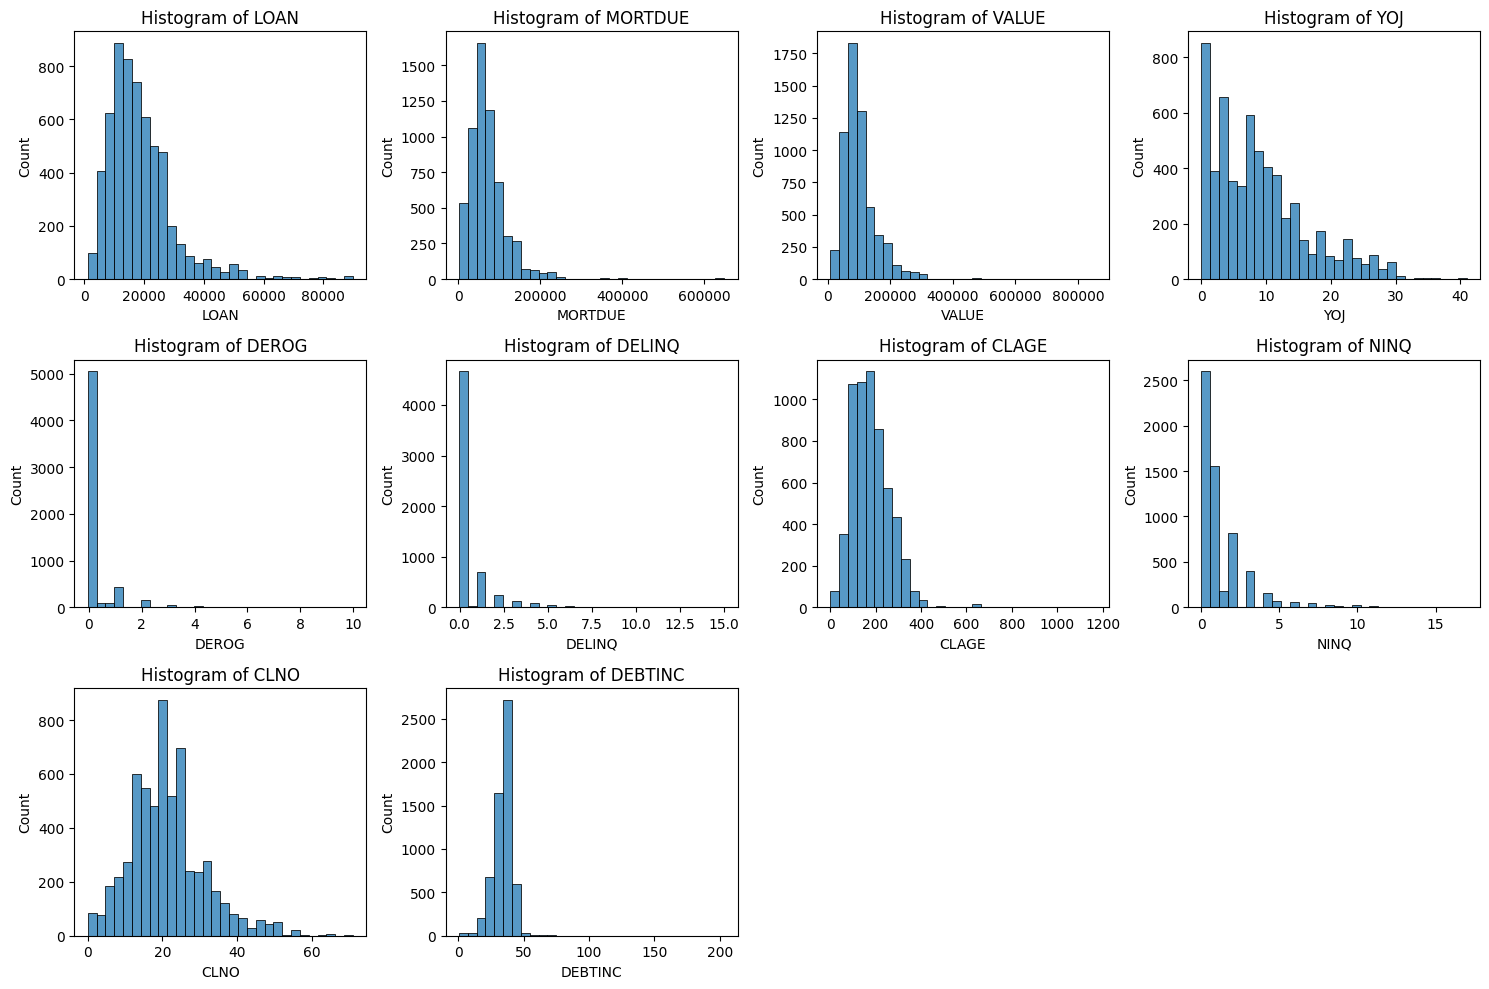

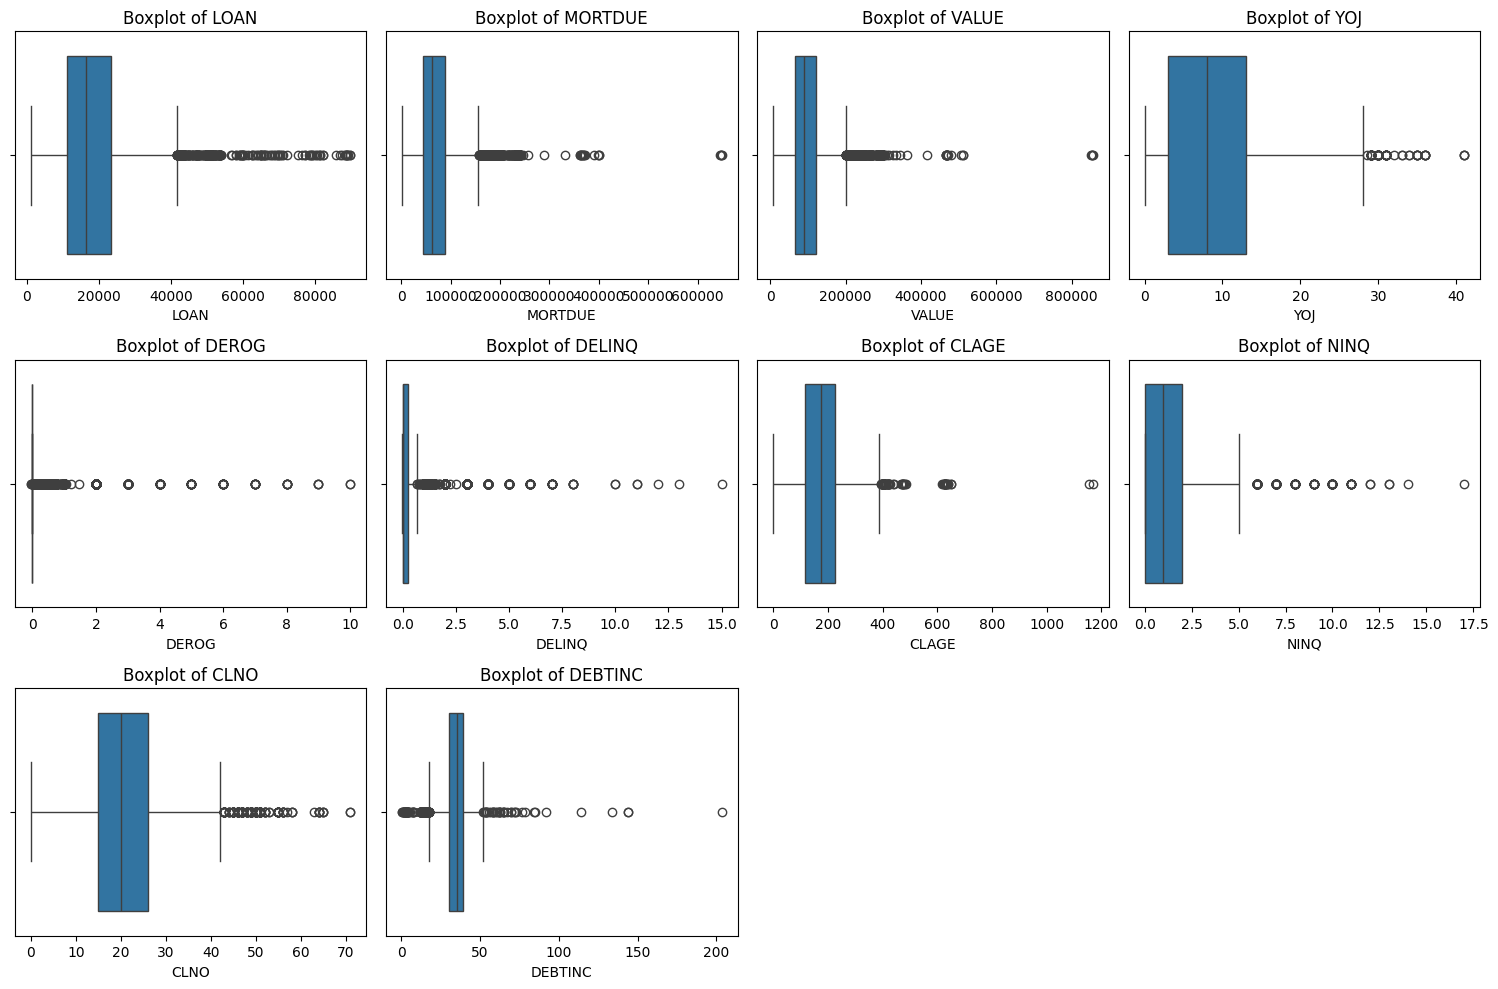

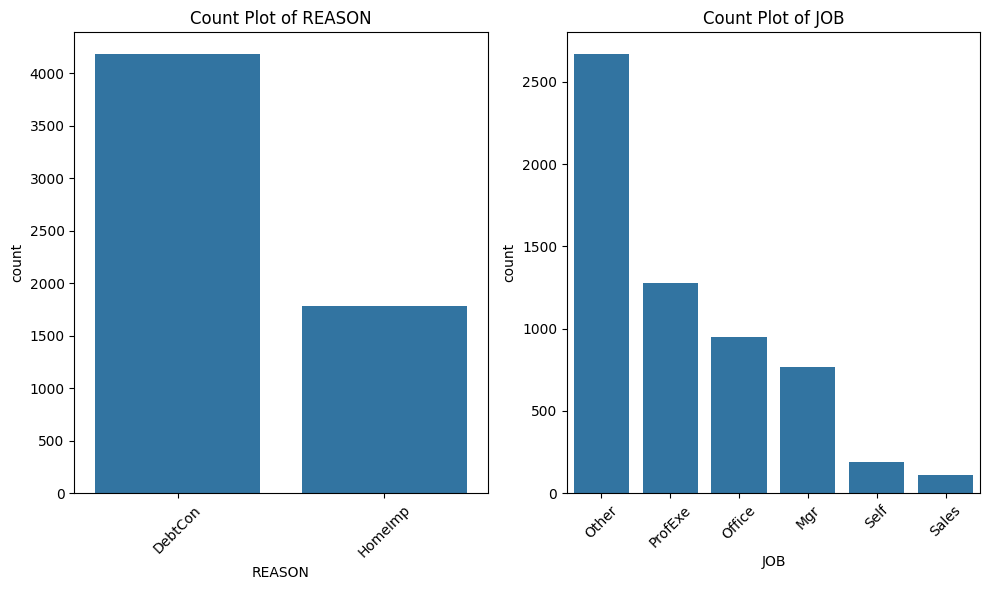

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# Numeric variables
# --------------------------
num_vars = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", 
            "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df_imputed[col], kde=False, bins=30)
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df_imputed[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# --------------------------
# Categorical variables
# --------------------------
cat_vars = ["REASON", "JOB"]

plt.figure(figsize=(10, 6))
for i, col in enumerate(cat_vars, 1):
    plt.subplot(1, len(cat_vars), i)
    sns.countplot(x=df_imputed[col], order=df_imputed[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)  # Rotate labels if too long
plt.tight_layout()
plt.show()




In [6]:
# --- Ensure DELINQ is an integer count after imputation ---
df_imputed['DELINQ'] = (
    pd.to_numeric(df_imputed['DELINQ'], errors='coerce')
      .round()
      .clip(lower=0)
      .astype('Int64')
)

# --- Defaults by delinquency bucket (count + rate) ---
delinq_summary = (
    df_imputed.groupby('DELINQ', dropna=False)
              .agg(total_customers=('BAD', 'size'),
                   defaults=('BAD', 'sum'))
              .assign(default_rate_pct=lambda d: 100 * d['defaults'] / d['total_customers'])
              .reset_index()
              .sort_values('DELINQ')
)

print("Defaults by delinquency bucket:\n", delinq_summary)

# --- How many customers in 0-delinquency, and how many defaulted there? ---
clean = delinq_summary.loc[delinq_summary['DELINQ'].fillna(-1).eq(0)]
n_clean = int(clean['total_customers'].iloc[0]) if not clean.empty else 0
n_clean_defaults = int(clean['defaults'].iloc[0]) if not clean.empty else 0

print(f"\n0-delinquency customers: {n_clean}")
print(f"Defaults within 0-delinquency: {n_clean_defaults}")

# (Optional) Good/Bad cross-tab by bucket
ct = pd.crosstab(df_imputed['DELINQ'], df_imputed['BAD'], rownames=['DELINQ'], colnames=['BAD'])
print("\nGood/Bad cross-tab (BAD: 0=good, 1=default):\n", ct)


Defaults by delinquency bucket:
     DELINQ  total_customers  defaults  default_rate_pct
0        0             4666       584         12.516074
1        1              735       285         38.775510
2        2              262       120         45.801527
3        3              129        71         55.038760
4        4               78        46         58.974359
5        5               38        31         81.578947
6        6               27        27        100.000000
7        7               13        13        100.000000
8        8                5         5        100.000000
9       10                2         2        100.000000
10      11                2         2        100.000000
11      12                1         1        100.000000
12      13                1         1        100.000000
13      15                1         1        100.000000

0-delinquency customers: 4666
Defaults within 0-delinquency: 584

Good/Bad cross-tab (BAD: 0=good, 1=default):
 BAD        0  

Value counts of BAD variable:
BAD
0    4771
1    1189
Name: count, dtype: int64

Percentage distribution:
BAD
0    80.050336
1    19.949664
Name: proportion, dtype: float64


/tmp/ipykernel_65/471958515.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='BAD', data=df, palette='pastel')


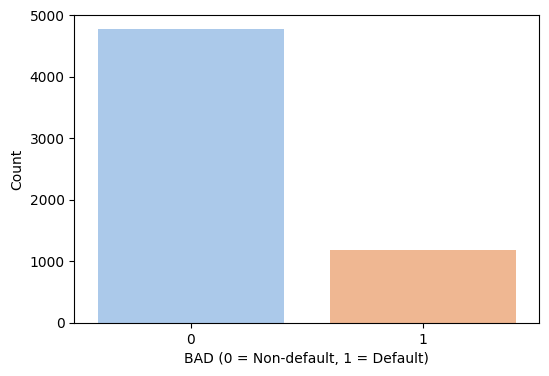

In [7]:
# Distribution of 'BAD' variable
print("Value counts of BAD variable:")
print(df['BAD'].value_counts())

# Display percentage distribution
print("\nPercentage distribution:")
print(df['BAD'].value_counts(normalize=True) * 100)

# Optional: Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='BAD', data=df, palette='pastel')

plt.xlabel('BAD (0 = Non-default, 1 = Default)')
plt.ylabel('Count')
plt.show()


In [8]:
import numpy as np
import pandas as pd

numeric_cols = ['YOJ','DEROG','DELINQ','CLAGE','NINQ','CLNO','DEBTINC','MORTDUE','VALUE','LOAN']
lower_q, upper_q = 0.01, 0.99  # 1st and 99th

# Compute caps from the single dataframe
def compute_caps_single(df, cols, lower=0.01, upper=0.99):
    caps = {}
    for col in cols:
        low, high = df[col].quantile([lower, upper])
        caps[col] = (low, high)
    return caps

pooled_caps = compute_caps_single(df_imputed, numeric_cols, lower_q, upper_q)

# Apply caps to a single dataframe
def cap_outliers(df, cols, caps):
    out = df.copy()
    for col in cols:
        low, high = caps[col]
        out[col] = np.clip(out[col], low, high)
    return out

train_capped = cap_outliers(df_imputed, numeric_cols, pooled_caps)
print("Post-capping ranges:")
for col, (low, high) in pooled_caps.items():
    print(f"{col}: min={train_capped[col].min():.3f}, max={train_capped[col].max():.3f}, caps=({low:.3f}, {high:.3f})")


Post-capping ranges:
YOJ: min=0.000, max=29.941, caps=(0.000, 29.941)
DEROG: min=0.000, max=4.000, caps=(0.000, 4.000)
DELINQ: min=0.000, max=5.000, caps=(0.000, 5.000)
CLAGE: min=31.999, max=398.565, caps=(31.999, 398.565)
NINQ: min=0.000, max=8.000, caps=(0.000, 8.000)
CLNO: min=0.000, max=50.000, caps=(0.000, 50.000)
DEBTINC: min=14.328, max=47.871, caps=(14.328, 47.871)
MORTDUE: min=7791.700, max=232079.960, caps=(7791.700, 232079.960)
VALUE: min=26063.798, max=290015.990, caps=(26063.798, 290015.990)
LOAN: min=3359.000, max=60869.000, caps=(3359.000, 60869.000)


In [9]:
from scipy.stats import pointbiserialr

# Separate numeric variables (excluding target BAD itself)
num_vars = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", 
            "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

# Dictionary to store results
pb_corr = {}

for col in num_vars:
    corr, pval = pointbiserialr(df_imputed["BAD"], df_imputed[col])
    pb_corr[col] = {"Correlation": corr, "p-value": pval}

# Convert to DataFrame for nice display
pb_corr_df = pd.DataFrame(pb_corr).T.sort_values("Correlation", ascending=False)

print(pb_corr_df)







         Correlation        p-value
DELINQ      0.367979  1.614269e-190
DEROG       0.283279  2.178774e-110
DEBTINC     0.282696  6.349850e-110
NINQ        0.179802   1.740219e-44
CLNO       -0.003601   7.810745e-01
VALUE      -0.027295   3.510312e-02
MORTDUE    -0.027515   3.365742e-02
YOJ        -0.067395   1.911264e-07
LOAN       -0.075099   6.448273e-09
CLAGE      -0.174323   7.007482e-42


In [10]:
import numpy as np
import pandas as pd
from scipy import stats

def welch_ttest(x, y):
    """Perform Welch's t-test, return t-stat, df, and p-value."""
    # Drop NaNs
    x = x.dropna()
    y = y.dropna()
    nx, ny = len(x), len(y)
    mean_x, mean_y = x.mean(), y.mean()
    var_x, var_y = x.var(ddof=1), y.var(ddof=1)
    
    # Welch's t statistic
    t_stat = (mean_x - mean_y) / np.sqrt(var_x/nx + var_y/ny)
    
    # Welch–Satterthwaite equation for df
    df_num = (var_x/nx + var_y/ny)**2
    df_den = ((var_x/nx)**2 / (nx-1)) + ((var_y/ny)**2 / (ny-1))
    df = df_num / df_den
    
    # Two-sided p-value
    p_val = 2 * stats.t.sf(np.abs(t_stat), df)
    
    return t_stat, df, p_val

# Example usage on your numeric predictors
num_vars = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", 
            "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

welch_results = {}

for col in num_vars:
    g0 = df_imputed.loc[df_imputed["BAD"] == 0, col]
    g1 = df_imputed.loc[df_imputed["BAD"] == 1, col]
    
    t_stat, df, p_val = welch_ttest(g0, g1)
    
    welch_results[col] = {
        "mean_BAD0": g0.mean(),
        "mean_BAD1": g1.mean(),
        "t-statistic": t_stat,
        "df": df,
        "p-value": p_val
    }

welch_df = pd.DataFrame(welch_results).T.sort_values("p-value")
print(welch_df.round(4))


           mean_BAD0   mean_BAD1  t-statistic         df  p-value
DELINQ        0.2245      1.2212     -18.3352  1261.1332   0.0000
DEBTINC      33.2558     38.8462     -17.3875  1428.1572   0.0000
CLAGE       185.9811    149.3720      13.7117  1833.3788   0.0000
DEROG         0.1440      0.7096     -13.5926  1257.8156   0.0000
NINQ          1.0308      1.7786     -11.2274  1468.7090   0.0000
LOAN      19028.1073  16922.1194       5.7200  1790.5455   0.0000
YOJ           9.2609      8.0336       5.4117  1914.8770   0.0000
MORTDUE   72033.1313  68844.9880       1.7890  1534.3427   0.0738
VALUE    102595.9092  98669.8655       1.7333  1505.5543   0.0832
CLNO         21.2693     21.1796       0.2477  1612.8574   0.8044


In [11]:
from scipy.stats import ttest_ind

# Numeric predictors (excluding BAD)
num_vars = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", 
            "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

t_test_results = {}

for col in num_vars:
    group0 = df_imputed.loc[df_imputed["BAD"] == 0, col]
    group1 = df_imputed.loc[df_imputed["BAD"] == 1, col]
    
    # Independent t-test (Welch's, does not assume equal variance)
    t_stat, p_val = ttest_ind(group0, group1, nan_policy="omit", equal_var=False)
    
    t_test_results[col] = {"t-statistic": t_stat, "p-value": p_val,
                           "mean_BAD0": group0.mean(), "mean_BAD1": group1.mean()}

# Convert to DataFrame for easy viewing
t_test_df = pd.DataFrame(t_test_results).T.sort_values("p-value")

print(t_test_df)

import numpy as np
from scipy.stats import ttest_ind

def cohens_d(x, y):
    # Drop NaNs
    x = x.dropna()
    y = y.dropna()
    nx, ny = len(x), len(y)
    
    # Means and std
    mean_x, mean_y = x.mean(), y.mean()
    std_x, std_y = x.std(), y.std()
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((nx - 1) * std_x**2 + (ny - 1) * std_y**2) / (nx + ny - 2))
    
    return (mean_x - mean_y) / pooled_std

# Numeric predictors
num_vars = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG", 
            "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC"]

results = {}

for col in num_vars:
    group0 = df_imputed.loc[df_imputed["BAD"] == 0, col]
    group1 = df_imputed.loc[df_imputed["BAD"] == 1, col]
    
    # Welch's t-test
    t_stat, p_val = ttest_ind(group0, group1, nan_policy="omit", equal_var=False)
    
    # Cohen's d (group0 vs group1)
    d = cohens_d(group0, group1)
    
    results[col] = {
        "t-statistic": t_stat,
        "p-value": p_val,
        "mean_BAD0": group0.mean(),
        "mean_BAD1": group1.mean(),
        "Cohen_d": d
    }

results_df = pd.DataFrame(results).T.sort_values("Cohen_d", key=abs, ascending=False)

print(results_df)


         t-statistic       p-value      mean_BAD0     mean_BAD1
DELINQ    -18.335228  9.419005e-67       0.224481      1.221194
DEBTINC   -17.387482  1.426149e-61      33.255790     38.846179
CLAGE      13.711677  8.283557e-41     185.981125    149.372026
DEROG     -13.592619  2.304240e-39       0.143985      0.709567
NINQ      -11.227407  4.028588e-28       1.030846      1.778589
LOAN        5.720043  1.245534e-08   19028.107315  16922.119428
YOJ         5.411692  7.027492e-08       9.260879      8.033595
MORTDUE     1.789003  7.381149e-02   72033.131350  68844.987952
VALUE       1.733319  8.324378e-02  102595.909191  98669.865497
CLNO        0.247677  8.044156e-01      21.269296     21.179566
         t-statistic       p-value      mean_BAD0     mean_BAD1   Cohen_d
DELINQ    -18.335228  9.419005e-67       0.224481      1.221194 -0.990137
DEROG     -13.592619  2.304240e-39       0.143985      0.709567 -0.739019
DEBTINC   -17.387482  1.426149e-61      33.255790     38.846179 -0.737368


In [12]:
import pandas as pd
from scipy.stats import chi2_contingency

cat_vars = ["JOB", "REASON"]
chi_results = {}

for col in cat_vars:
    # Create contingency table
    contingency = pd.crosstab(df_imputed[col], df_imputed["BAD"])
    
    # Run Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    chi_results[col] = {
        "Chi2 Statistic": chi2,
        "p-value": p,
        "Degrees of Freedom": dof
    }

chi_df = pd.DataFrame(chi_results).T
print(chi_df)


        Chi2 Statistic       p-value  Degrees of Freedom
JOB          73.815093  1.643694e-14                 5.0
REASON        8.185164  4.223437e-03                 1.0


In [13]:
import pandas as pd
import numpy as np

# ---------------------------------
# Custom 3-bin bucketing for counts
# ---------------------------------
count_vars = ["DEROG", "DELINQ", "NINQ"]

# If df_imputed is already fully imputed, NaNs shouldn't exist.
# Create fixed 3-category bins: 0 | 1-2 | 3+
for col in count_vars:
    df_imputed[col + "_BIN"] = pd.cut(
        df_imputed[col], 
        bins=[-0.1, 0.5,1.5, 2.5, np.inf], 
        labels=["0", "1","2", "3+"], 
        include_lowest=True
    )

# ---------------------------------
# WOE/IV helper
# ---------------------------------
def calc_woe_iv(df, feature, target="BAD"):
    temp = pd.crosstab(df[feature], df[target]).reindex(columns=[0, 1], fill_value=0)
    temp.columns = ["Good", "Bad"]
    temp["Good"] = temp["Good"].astype(float) + 0.5
    temp["Bad"]  = temp["Bad"].astype(float)  + 0.5
    temp["Distr_Good"] = temp["Good"] / temp["Good"].sum()
    temp["Distr_Bad"]  = temp["Bad"]  / temp["Bad"].sum()
    temp["WOE"] = np.log(temp["Distr_Good"] / temp["Distr_Bad"])
    temp["IV_Contribution"] = (temp["Distr_Good"] - temp["Distr_Bad"]) * temp["WOE"]
    iv = temp["IV_Contribution"].sum()
    return temp[["Good","Bad","Distr_Good","Distr_Bad","WOE","IV_Contribution"]], iv

# ---------------------------------
# Run WOE/IV for all predictors
# ---------------------------------
woe_iv_results = {}
predictors = ["LOAN", "MORTDUE", "VALUE", "YOJ", "DEROG",
              "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC",
              "JOB", "REASON"]

for col in predictors:
    if col in count_vars:
        # Use the custom 3-category bins we just built
        woe_table, iv = calc_woe_iv(df_imputed, col + "_BIN", target="BAD")
    elif pd.api.types.is_numeric_dtype(df_imputed[col]):
        # Other numeric variables -> deciles (duplicates dropped if needed)
        df_imputed[col + "_BIN"] = pd.qcut(df_imputed[col], q=10, duplicates="drop")
        woe_table, iv = calc_woe_iv(df_imputed, col + "_BIN", target="BAD")
    else:
        # Categorical as-is
        woe_table, iv = calc_woe_iv(df_imputed, col, target="BAD")

    woe_iv_results[col] = {"IV": iv, "WOE_Table": woe_table}

# ---------------------------------
# IV summary
# ---------------------------------
iv_summary = pd.DataFrame({k: v["IV"] for k, v in woe_iv_results.items()}, index=["IV"]).T
iv_summary = iv_summary.sort_values("IV", ascending=False)
print(iv_summary)

# ---------------------------------
# Bin count summary (how many bins used)
# ---------------------------------
bin_summary = {}
for col in predictors:
    if col in count_vars:
        n_bins = df_imputed[col + "_BIN"].nunique()
    elif pd.api.types.is_numeric_dtype(df_imputed[col]):
        n_bins = df_imputed[col + "_BIN"].nunique()
    else:
        n_bins = df_imputed[col].nunique()
    bin_summary[col] = {"IV": woe_iv_results[col]["IV"], "Bins": n_bins}

bin_summary_df = pd.DataFrame(bin_summary).T.sort_values("IV", ascending=False)
print(bin_summary_df)

for col in woe_iv_results:
    print(f"{col}:\n", woe_iv_results[col]["WOE_Table"], "\n")


               IV
DEBTINC  0.870669
DELINQ   0.737010
DEROG    0.531362
CLAGE    0.272323
NINQ     0.195259
LOAN     0.159068
VALUE    0.097106
JOB      0.078008
CLNO     0.060751
YOJ      0.053717
MORTDUE  0.052122
REASON   0.008655
               IV  Bins
DEBTINC  0.870669  10.0
DELINQ   0.737010   4.0
DEROG    0.531362   4.0
CLAGE    0.272323  10.0
NINQ     0.195259   4.0
LOAN     0.159068  10.0
VALUE    0.097106  10.0
JOB      0.078008   6.0
CLNO     0.060751  10.0
YOJ      0.053717  10.0
MORTDUE  0.052122  10.0
REASON   0.008655   2.0
LOAN:
                      Good    Bad  Distr_Good  Distr_Bad       WOE  \
LOAN_BIN                                                            
(1099.999, 7600.0]  374.5  229.5    0.078413   0.192211 -0.896606   
(7600.0, 10000.0]   471.5  137.5    0.098723   0.115159 -0.153999   
(10000.0, 12100.0]  476.5  106.5    0.099770   0.089196  0.112028   
(12100.0, 14400.0]  503.5  107.5    0.105423   0.090034  0.157799   
(14400.0, 16300.0]  447.5  131.5 

/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py


ROC AUC: 0.871398
Confusion Matrix (threshold=0.5):
[[1124  307]
 [  80  277]]

Classification Report:
              precision    recall  f1-score   support

           0      0.934     0.785     0.853      1431
           1      0.474     0.776     0.589       357

    accuracy                          0.784      1788
   macro avg      0.704     0.781     0.721      1788
weighted avg      0.842     0.784     0.800      1788



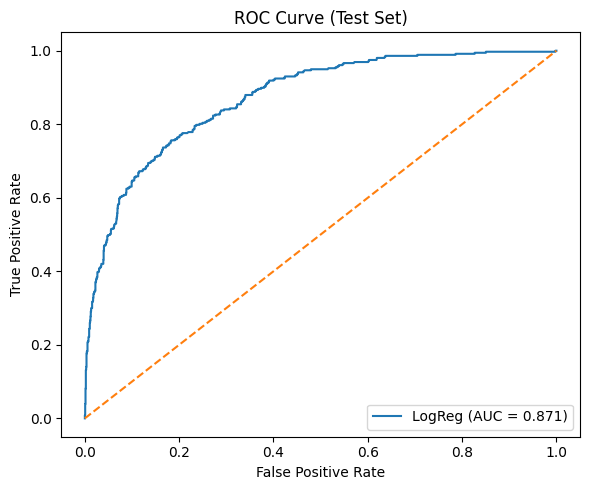

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# ----------------------------
# 1) Config
# ----------------------------
target = "BAD"
count_like = ["DELINQ", "DEROG", "NINQ"]        # <-- JOB removed from here
continuous = ["DEBTINC", "CLAGE", "LOAN"]
categoricals = ["JOB"]                          # <-- JOB handled as categorical
predictors = count_like + continuous + categoricals

# Ensure types
df_imputed = df_imputed.copy()
df_imputed[target] = df_imputed[target].astype(int)
df_imputed["JOB"] = df_imputed["JOB"].fillna("Missing").astype(str)

# ----------------------------
# 2) Split (stratified)
# ----------------------------
X = df_imputed[predictors].copy()
y = df_imputed[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ----------------------------
# 3) Binning (TRAIN-only) for numeric/count vars
# ----------------------------
def manual_count_binner(s: pd.Series) -> pd.Series:
    return pd.cut(
        s.clip(lower=0),
        bins=[-0.1, 0.5, 1.5, 2.5, s.max() + 1],
        labels=[0, 1, 2, 3],
        include_lowest=True
    ).astype(int)

def fit_quantile_binner(x_train: pd.Series, max_bins: int = 10):
    n_unique = x_train.nunique()
    n_bins = int(max(2, min(max_bins, n_unique)))
    kb = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
    kb.fit(x_train.to_frame())
    return kb

# Create BIN columns for numeric/count predictors only
X_train_bins = pd.DataFrame(index=X_train.index)
X_test_bins  = pd.DataFrame(index=X_test.index)

# Count-like
for col in count_like:
    X_train_bins[col + "_BIN"] = manual_count_binner(X_train[col])
    X_test_bins[col + "_BIN"]  = manual_count_binner(X_test[col])

# Continuous
kbinners = {}
for col in continuous:
    kb = fit_quantile_binner(X_train[col], max_bins=10)
    X_train_bins[col + "_BIN"] = kb.transform(X_train[[col]]).astype(int).ravel()
    X_test_bins[col + "_BIN"]  = kb.transform(X_test[[col]]).astype(int).ravel()
    kbinners[col] = kb

# ----------------------------
# 4) WOE maps (TRAIN-only) + mapping
# ----------------------------
def woe_map_from_train(keys: pd.Series, y_tr: pd.Series) -> dict:
    ct = pd.crosstab(keys, y_tr).reindex(columns=[0, 1], fill_value=0)
    good = ct[0].astype(float) + 0.5
    bad  = ct[1].astype(float) + 0.5
    woe = np.log((good/good.sum()) / (bad/bad.sum()))
    return woe.to_dict()

X_train_woe = pd.DataFrame(index=X_train.index)
X_test_woe  = pd.DataFrame(index=X_test.index)

# 4a) Numeric/count: BIN -> WOE
for col in count_like + continuous:
    m = woe_map_from_train(X_train_bins[col + "_BIN"], y_train)
    X_train_woe[col + "_WOE"] = X_train_bins[col + "_BIN"].map(m).astype(float)
    X_test_woe[col + "_WOE"]  = X_test_bins[col + "_BIN"].map(m).fillna(0.0).astype(float)

# 4b) Categorical JOB: WOE directly (NO BIN)
job_map = woe_map_from_train(X_train["JOB"], y_train)
X_train_woe["JOB_WOE"] = X_train["JOB"].map(job_map).astype(float)
X_test_woe["JOB_WOE"]  = X_test["JOB"].map(job_map).fillna(0.0).astype(float)

woe_features = X_train_woe.columns.tolist()

# ----------------------------
# 5) SMOTE on TRAIN (after WOE)
# ----------------------------
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train_woe, y_train)

# ----------------------------
# 6) Logistic Regression
# ----------------------------
clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train_bal, y_train_bal)

# ----------------------------
# 7) Evaluation on TEST
# ----------------------------
y_score = clf.predict_proba(X_test_woe)[:, 1]
y_pred  = (y_score >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_score)
cm = confusion_matrix(y_test, y_pred)

print(f"\nROC AUC: {roc_auc:.6f}")
print("Confusion Matrix (threshold=0.5):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()







/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py

Class dist before SMOTE: [3340  832]
Class dist after  SMOTE: [3340 3340]

ROC AUC: 0.910971
Confusion Matrix (threshold=0.5):
[[1352   79]
 [ 122  235]]

Classification Report:
               precision    recall  f1-score   support

           0      0.917     0.945     0.931      1431
           1      0.748     0.658     0.700       357

    accuracy                          0.888      1788
   macro avg      0.833     0.802     0.816      1788
weighted avg      0.884     0.888     0.885      1788



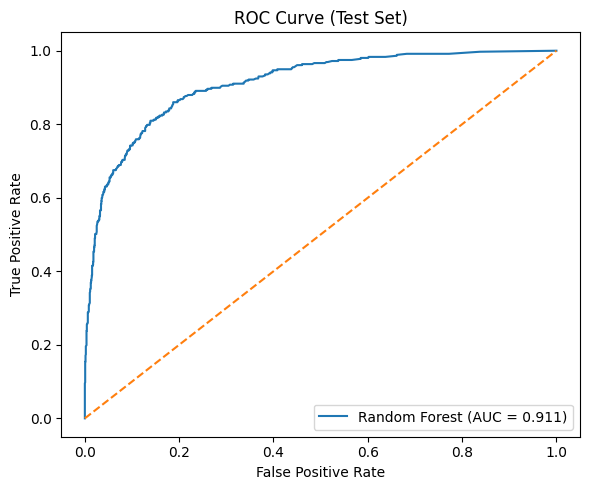


Feature importances:
 DEBTINC_WOE    0.257677
CLAGE_WOE      0.173681
LOAN_WOE       0.144396
DELINQ_WOE     0.129955
JOB_WOE        0.111713
NINQ_WOE       0.109529
DEROG_WOE      0.073049
dtype: float64


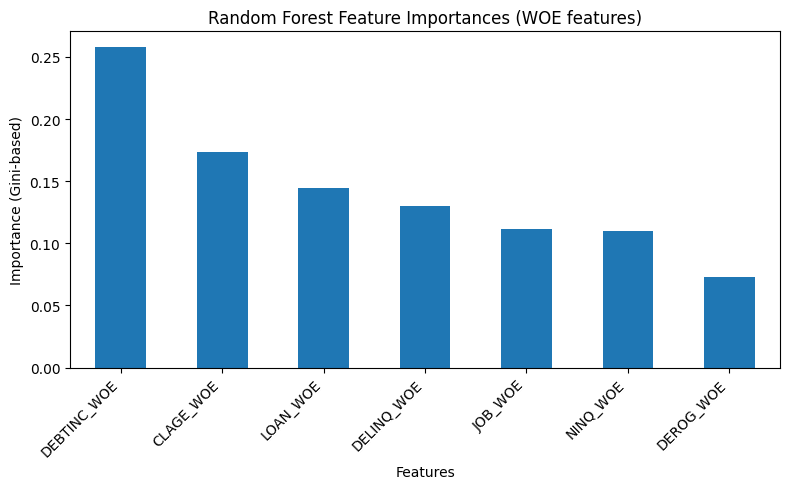

In [15]:
# Random Forest with Train-only WOE (incl. JOB), SMOTE, ROC/CM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 1) Config
target = "BAD"
count_like   = ["DELINQ", "DEROG", "NINQ"]
continuous   = ["DEBTINC", "CLAGE", "LOAN"]
categoricals = ["JOB"]
predictors   = count_like + continuous + categoricals

# 2) Prep + split (stratified)
df = df_imputed.copy()
df[target] = df[target].astype(int)
for c in categoricals:
    df[c] = df[c].fillna("Missing").astype(str)

X_raw = df[predictors]
y     = df[target]

Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)

# 3) Binning on TRAIN (count-like & continuous), then apply to TEST
def manual_count_binner(s: pd.Series) -> pd.Series:
    """
    Bin integer-ish counts to 4 buckets: 0, 1, 2, 3+
    """
    # use nanmax in case of NaNs; add a small buffer for the top edge
    top = np.nanmax(s.values) if np.isfinite(np.nanmax(s.values)) else 0
    return pd.cut(
        s.clip(lower=0),
        bins=[-0.1, 0.5, 1.5, 2.5, top + 1],
        labels=["0", "1", "2", "3+"],  # <-- missing comma fixed here
        include_lowest=True
    )

def fit_quantile_binner(x_train: pd.Series, max_bins: int = 10):
    n_bins = int(max(2, min(max_bins, x_train.nunique())))
    kb = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
    kb.fit(x_train.to_frame())
    return kb

Xtr_bins = pd.DataFrame(index=Xtr_raw.index)
Xte_bins = pd.DataFrame(index=Xte_raw.index)

# count-like
for col in count_like:
    Xtr_bins[col + "_BIN"] = manual_count_binner(Xtr_raw[col])
    Xte_bins[col + "_BIN"] = manual_count_binner(Xte_raw[col])

# continuous
kbinners = {}
for col in continuous:
    kb = fit_quantile_binner(Xtr_raw[col], max_bins=10)
    Xtr_bins[col + "_BIN"] = kb.transform(Xtr_raw[[col]]).astype(int).ravel()
    Xte_bins[col + "_BIN"] = kb.transform(Xte_raw[[col]]).astype(int).ravel()
    kbinners[col] = kb

# 4) WOE encoding FROM TRAIN ONLY (0.5 smoothing)
def woe_map_from_train(keys: pd.Series, y_train: pd.Series) -> dict:
    keys = keys.astype(str)  # robust against Categorical/Interval
    ct = pd.crosstab(keys, y_train).reindex(columns=[0, 1], fill_value=0)
    good = ct[0].astype(float) + 0.5
    bad  = ct[1].astype(float) + 0.5
    woe = np.log((good / good.sum()) / (bad / bad.sum()))
    return woe.to_dict()

Xtr_woe = pd.DataFrame(index=Xtr_raw.index)
Xte_woe = pd.DataFrame(index=Xte_raw.index)

# Numeric (via BIN -> WOE)
for col in count_like + continuous:
    m = woe_map_from_train(Xtr_bins[col + "_BIN"], ytr)
    Xtr_woe[col + "_WOE"] = Xtr_bins[col + "_BIN"].astype(str).map(m).astype(float).fillna(0.0)
    Xte_woe[col + "_WOE"] = Xte_bins[col + "_BIN"].astype(str).map(m).astype(float).fillna(0.0)

# Categorical (direct category -> WOE)
for col in categoricals:
    m = woe_map_from_train(Xtr_raw[col], ytr)
    Xtr_woe[col + "_WOE"] = Xtr_raw[col].astype(str).map(m).astype(float).fillna(0.0)
    Xte_woe[col + "_WOE"] = Xte_raw[col].astype(str).map(m).astype(float).fillna(0.0)

woe_features = Xtr_woe.columns.tolist()

# 5) SMOTE on TRAIN (after WOE)
sm = SMOTE(random_state=42, k_neighbors=5)
Xtr_bal, ytr_bal = sm.fit_resample(Xtr_woe, ytr)
print("Class dist before SMOTE:", np.bincount(ytr))
print("Class dist after  SMOTE:", np.bincount(ytr_bal))

# 6) Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf.fit(Xtr_bal, ytr_bal)

# 7) Evaluation on TEST
y_score = rf.predict_proba(Xte_woe)[:, 1]
y_pred  = (y_score >= 0.5).astype(int)

auc = roc_auc_score(yte, y_score)
cm  = confusion_matrix(yte, y_pred)
print(f"\nROC AUC: {auc:.6f}")
print("Confusion Matrix (threshold=0.5):")
print(cm)
print("\nClassification Report:\n", classification_report(yte, y_pred, digits=3))

# ROC curve
fpr, tpr, _ = roc_curve(yte, y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 8) Feature importances (RF on WOE features)
fi = pd.Series(rf.feature_importances_, index=woe_features).sort_values(ascending=False)
print("\nFeature importances:\n", fi)

# --- Plot feature importances ---
plt.figure(figsize=(8,5))
fi.plot(kind="bar")
plt.title("Random Forest Feature Importances (WOE features)")
plt.ylabel("Importance (Gini-based)")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




  0% (0 of 7) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--

Class dist before SMOTE: [3340  832]
Class dist after  SMOTE: [3340 3340]


/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:148: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/pygam.py:630: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:132: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:133: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/pygam.py:630: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.p

did not converge


/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/utils.py:786: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/utils.py:786: RuntimeWarning: overflow encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 28% (2 of 7) |#######                   | Elapsed Time: 0:02:28 ETA:   0:06:11/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:132: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:133: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:148: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/work

did not converge


 42% (3 of 7) |###########               | Elapsed Time: 0:02:56 ETA:   0:03:55/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:132: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:133: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:148: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/links.py:148: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/workspaces/myfolder/.user-python-packages/lib/python3.11/site-packages/pygam/pygam.py:630: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/workspaces/m


GAM ROC AUC: 0.867557
Confusion Matrix (threshold=0.5):
[[1209  222]
 [ 102  255]]

Classification Report:
              precision    recall  f1-score   support

           0      0.922     0.845     0.882      1431
           1      0.535     0.714     0.612       357

    accuracy                          0.819      1788
   macro avg      0.728     0.780     0.747      1788
weighted avg      0.845     0.819     0.828      1788



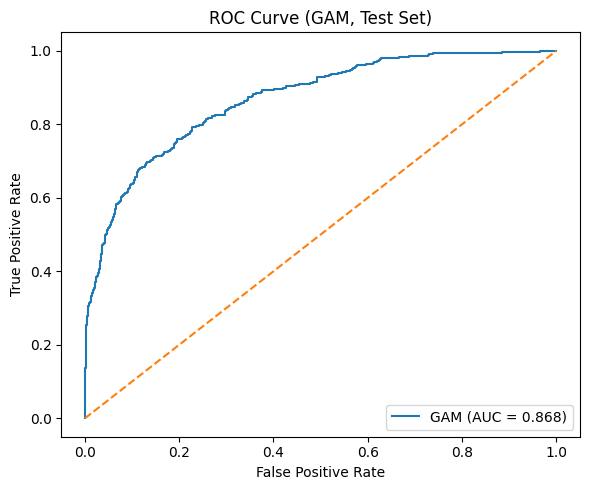

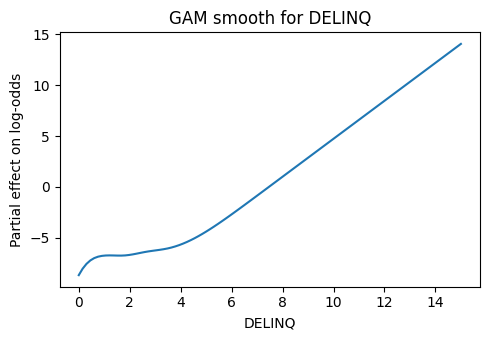

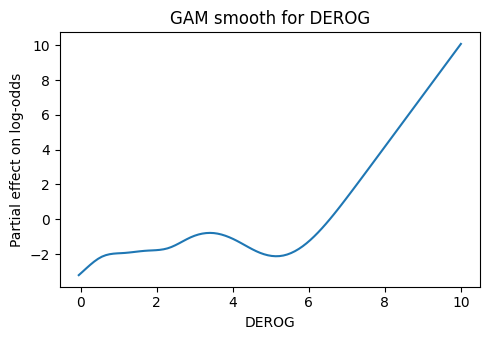

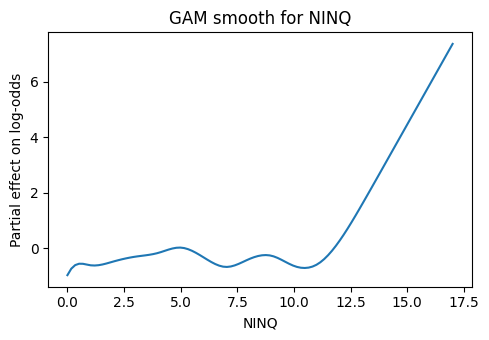

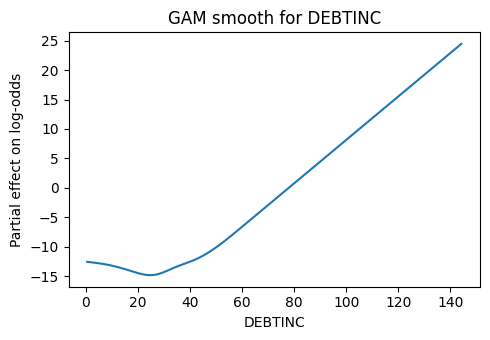

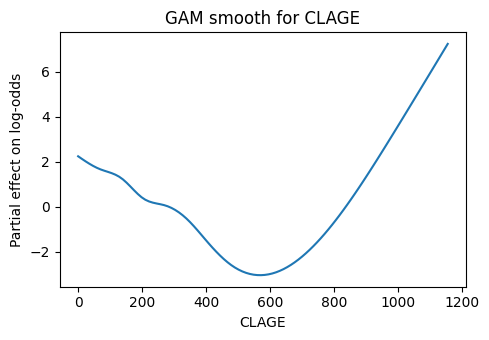

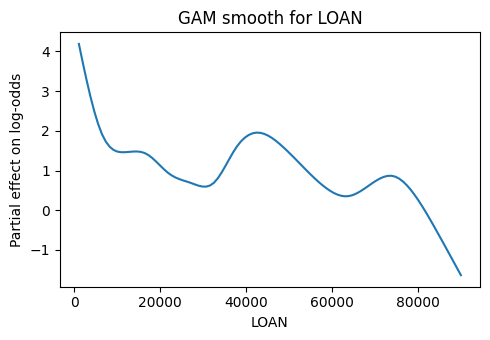

In [16]:
# ============================
# 0) Imports
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# pip install pygam (if needed)
from pygam import LogisticGAM, s, f

# ============================
# 1) Config
# ============================
target = "BAD"

# Core predictors (top ones you validated)
count_like = ["DELINQ", "DEROG", "NINQ"]       # integer-ish counts
continuous = ["DEBTINC", "CLAGE", "LOAN"]      # add/remove as you like

# Optional categorical factors (uncomment to include)
use_categoricals = False
categoricals = ["JOB"]

# Ensure no missing values (you said you have df_imputed already)
df_gam = df_imputed.copy()
df_gam[target] = df_gam[target].astype(int)

# If using categoricals, convert to integer codes for pygam's f() term
if use_categoricals:
    for c in categoricals:
        df_gam[c] = df_gam[c].astype("category").cat.codes  # -1 may appear for NAs if any

# Final feature order (kept stable for term indexing)
features = count_like + continuous + (categoricals if use_categoricals else [])

# ============================
# 2) Train/Test split (stratified)
# ============================
X = df_gam[features].values
y = df_gam[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ============================
# 3) SMOTE on TRAIN only
# ============================
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Class dist before SMOTE:", np.bincount(y_train))
print("Class dist after  SMOTE:", np.bincount(y_train_bal))

# ============================
# 4) Build GAM terms
#    - Smooth terms s() for numeric features
#    - Factor terms f() for categoricals (if enabled)
# The term indices must match the column order in `features`.
# ============================
terms = []

# count-like: still model as smooths (lets GAM learn nonlinearities)
for i in range(len(count_like)):
    terms.append(s(i))

# continuous smooths
offset = len(count_like)
for j in range(len(continuous)):
    terms.append(s(offset + j))

# optional factor terms
if use_categoricals:
    start_cat = len(count_like) + len(continuous)
    for k in range(len(categoricals)):
        terms.append(f(start_cat + k))

# Sum terms into a single model specification
gam_terms = terms[0]
for t in terms[1:]:
    gam_terms = gam_terms + t

# ============================
# 5) Fit LogisticGAM with a small gridsearch over lambda for smoothing
# ============================
# You can expand lam grid if you like (slower).
lam_grid = np.logspace(-3, 3, 7)

gam = LogisticGAM(gam_terms, verbose=False)
gam.gridsearch(X_train_bal, y_train_bal, lam=lam_grid)

# ============================
# 6) Evaluate on TEST
# ============================
# gam.predict_proba returns P(BAD=1)
y_score = gam.predict_proba(X_test)
y_pred  = (y_score >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_score)
cm = confusion_matrix(y_test, y_pred)

print(f"\nGAM ROC AUC: {roc_auc:.6f}")
print("Confusion Matrix (threshold=0.5):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"GAM (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GAM, Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================
# 7) Optional: partial dependence (shape functions)
# ============================
# Visualize learned smooths for interpretability
for idx, name in enumerate(features):
    if use_categoricals and name in categoricals:
        # skip factor plots here; pygam's partial_dependence for f() isn't as informative
        continue
    XX = gam.generate_X_grid(term=idx)
    plt.figure(figsize=(5,3.5))
    plt.plot(XX[:, idx], gam.partial_dependence(term=idx, X=XX))
    plt.xlabel(name)
    plt.ylabel("Partial effect on log-odds")
    plt.title(f"GAM smooth for {name}")
    plt.tight_layout()
    plt.show()



Gradient Boosting ROC AUC: 0.890383
Confusion Matrix (threshold=0.5):
[[1330  101]
 [ 123  234]]

Classification Report:
              precision    recall  f1-score   support

           0      0.915     0.929     0.922      1431
           1      0.699     0.655     0.676       357

    accuracy                          0.875      1788
   macro avg      0.807     0.792     0.799      1788
weighted avg      0.872     0.875     0.873      1788



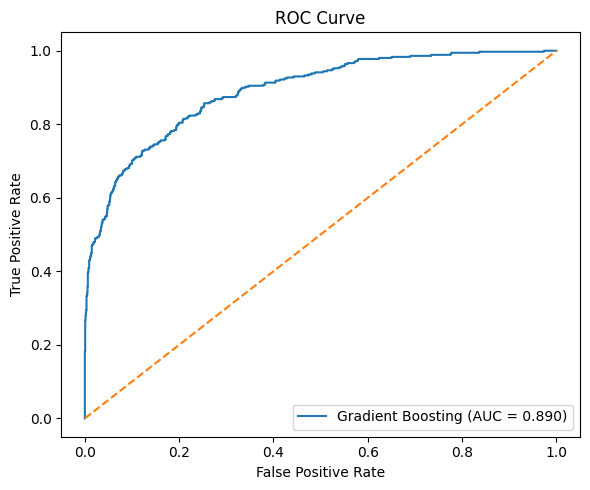


Top 15 feature importances:
   feature  importance
0   DELINQ    0.339575
3  DEBTINC    0.220858
2     NINQ    0.136796
1    DEROG    0.127884
4    CLAGE    0.109742
5     LOAN    0.065145


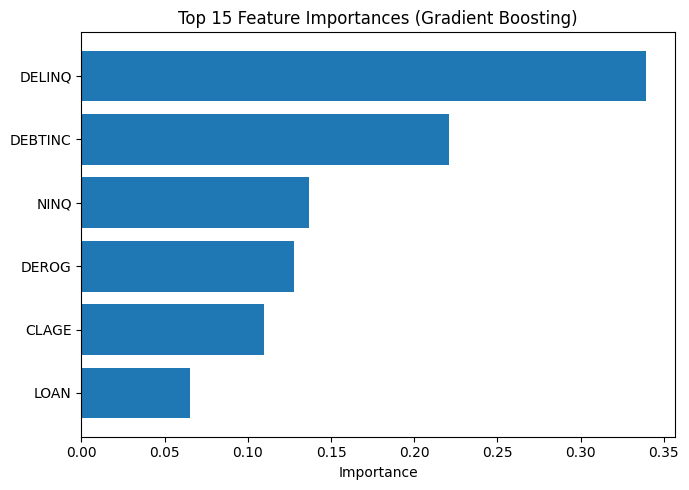

In [17]:
# ============================
# Gradient Boosting (sklearn)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# ----------------------------
# 0) Config (reuse your setup)
# ----------------------------
target = "BAD"

count_like = ["DELINQ", "DEROG", "NINQ"]       # integer-ish counts
continuous = ["DEBTINC", "CLAGE", "LOAN"]
use_categoricals = False                       # set True to include below
categoricals = ["JOB"]

# Expect df_imputed to exist already
df_gb = df_imputed.copy()
df_gb[target] = df_gb[target].astype(int)

# Final feature list (same order pattern as your GAM code)
features = count_like + continuous + (categoricals if use_categoricals else [])

# ----------------------------
# 1) Train/Test split
# ----------------------------
X = df_gb[features].copy()
y = df_gb[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ----------------------------
# 2) Preprocess + SMOTE + GB
# ----------------------------
# Numeric & categorical columns for transformer
num_cols = count_like + continuous
cat_cols = categoricals if use_categoricals else []

# OneHot for categoricals (dense so SMOTE can work)
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
       ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),

    ],
    remainder="drop",
)

# Gradient Boosting model (start with a solid baseline)
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,           # depth of individual trees (via max_depth if using sklearn>=1.6; older versions use max_depth via base_estimator params)
    subsample=0.9,
    random_state=42
)

# Full pipeline: preprocess -> SMOTE -> GB
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("gb", gb_clf)
])

# Fit on TRAIN only (SMOTE happens only on train inside pipeline)
pipe.fit(X_train, y_train)

# ----------------------------
# 3) Evaluate on TEST
# ----------------------------
y_score = pipe.predict_proba(X_test)[:, 1]
y_pred  = (y_score >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_score)
cm = confusion_matrix(y_test, y_pred)

print(f"\nGradient Boosting ROC AUC: {roc_auc:.6f}")
print("Confusion Matrix (threshold=0.5):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ----------------------------
# 4) Feature Importances (top 15)
# ----------------------------
# Get feature names after preprocessing
# (ColumnTransformer provides get_feature_names_out in sklearn >= 1.0)
feature_names = []
feature_names.extend(num_cols)
if use_categoricals and len(cat_cols) > 0:
    # Get one-hot names for categoricals
    ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names = num_cols + ohe_names

importances = pipe.named_steps["gb"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

print("\nTop 15 feature importances:")
print(imp_df)

plt.figure(figsize=(7,5))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.show()



Gradient Boosting ROC AUC: 0.887561
Confusion Matrix (threshold=0.5):
[[1319  112]
 [ 143  214]]

Classification Report:
              precision    recall  f1-score   support

           0      0.902     0.922     0.912      1431
           1      0.656     0.599     0.627       357

    accuracy                          0.857      1788
   macro avg      0.779     0.761     0.769      1788
weighted avg      0.853     0.857     0.855      1788



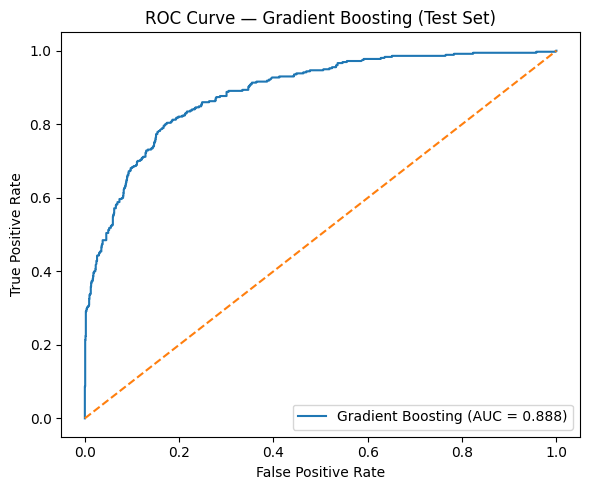


Top 15 feature importances (Gradient Boosting):
DEBTINC_WOE    0.343309
DELINQ_WOE     0.171274
CLAGE_WOE      0.149897
NINQ_WOE       0.096344
JOB_WOE        0.094717
LOAN_WOE       0.078118
DEROG_WOE      0.066342
dtype: float64


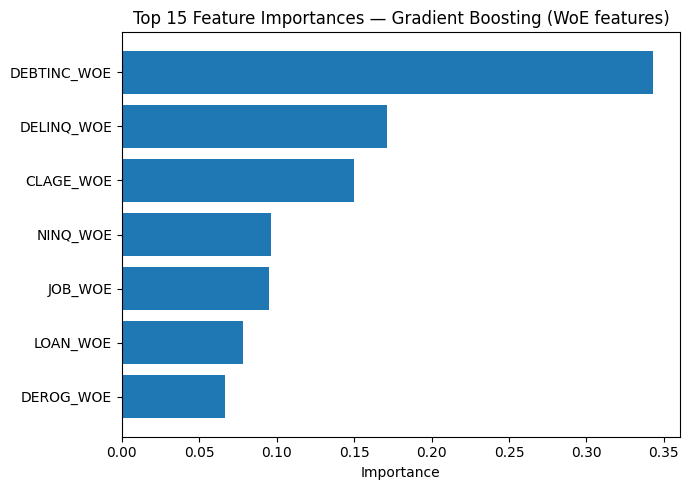

In [19]:
# ============================
# Gradient Boosting on WoE features
# ============================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Balance TRAIN with SMOTE (after WoE)
sm_gb = SMOTE(random_state=42, k_neighbors=5)
X_train_gb, y_train_gb = sm_gb.fit_resample(X_train_woe, y_train)

# 2) Train GB (solid baseline)
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,     # if your sklearn doesn't support max_depth directly, remove this line
    subsample=0.9,
    random_state=42
)
gb.fit(X_train_gb, y_train_gb)

# 3) Predict on TEST (no SMOTE on test)
y_score_gb = gb.predict_proba(X_test_woe)[:, 1]
y_pred_gb  = (y_score_gb >= 0.5).astype(int)

# 4) Metrics
auc_gb = roc_auc_score(y_test, y_score_gb)
cm_gb  = confusion_matrix(y_test, y_pred_gb)

print(f"\nGradient Boosting ROC AUC: {auc_gb:.6f}")
print("Confusion Matrix (threshold=0.5):")
print(cm_gb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, digits=3))

# 5) ROC curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_score_gb)
plt.figure(figsize=(6,5))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Gradient Boosting (Test Set)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

# 6) Feature importances (optional)
imp = pd.Series(gb.feature_importances_, index=X_train_woe.columns).sort_values(ascending=False)
print("\nTop 15 feature importances (Gradient Boosting):")
print(imp.head(15))

plt.figure(figsize=(7,5))
plt.barh(imp.head(15).index[::-1], imp.head(15).values[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Gradient Boosting (WoE features)")
plt.tight_layout(); plt.show()


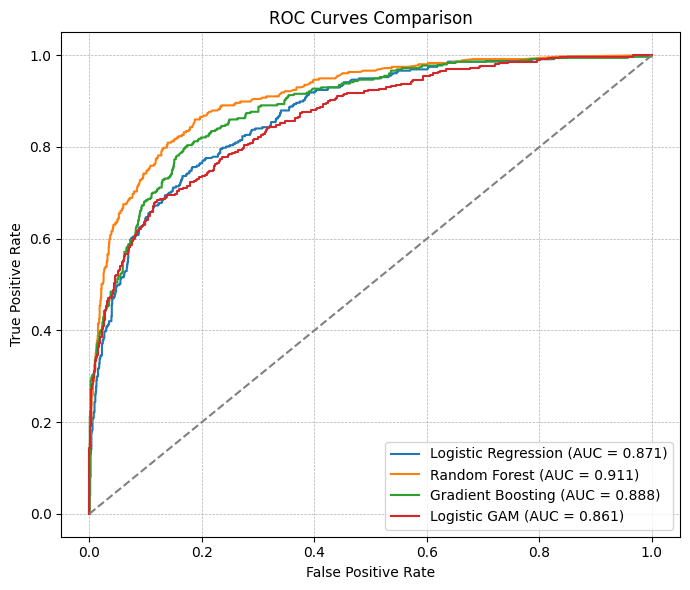

In [20]:
# ============================
# Add Logistic GAM to ROC comparison
# ============================

# 1) Predicted probabilities (AUCs)
y_score_lr  = clf.predict_proba(X_test_woe)[:, 1]
y_score_rf  = rf.predict_proba(X_test_woe)[:, 1]
y_score_gb  = gb.predict_proba(X_test_woe)[:, 1]

# For GAM: use the test matrix that matches how GAM was trained (no WOE)
y_score_gam = gam.predict_proba(X_test)   # P(BAD=1)

# (Optional safety check: make sure y_test aligns with all scores)
assert len(y_test) == len(y_score_lr) == len(y_score_rf) == len(y_score_gb) == len(y_score_gam)

# 2) Plot ROC curves for all four models
plt.figure(figsize=(7,6))

def add_curve(y_true, y_score, label):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_val:.3f})")

add_curve(y_test, y_score_lr,  "Logistic Regression")
add_curve(y_test, y_score_rf,  "Random Forest")
add_curve(y_test, y_score_gb,  "Gradient Boosting")
add_curve(y_test, y_score_gam, "Logistic GAM")

# Chance line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()



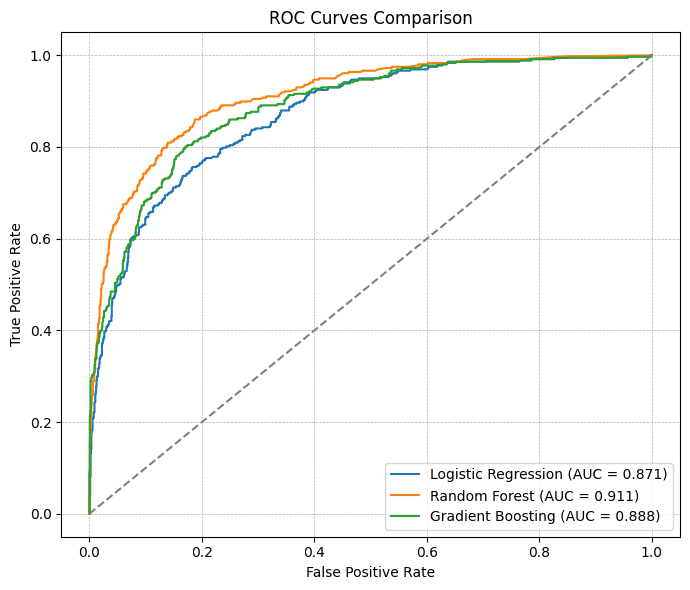

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ============================
# 1) Get predicted probabilities for each model
# ============================

# Logistic Regression (WOE features)
y_score_lr = clf.predict_proba(X_test_woe)[:, 1]
auc_lr = roc_auc_score(y_test, y_score_lr)

# Random Forest (WOE features)
y_score_rf = rf.predict_proba(X_test_woe)[:, 1]
auc_rf = roc_auc_score(y_test, y_score_rf)

# Gradient Boosting (WOE features)
y_score_gb = gb.predict_proba(X_test_woe)[:, 1]
auc_gb = roc_auc_score(y_test, y_score_gb)

# ============================
# 2) ROC curve for each model (LR, RF, GB)
# ============================
plt.figure(figsize=(7,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_score_gb)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")

# Chance line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()




=== 1) Affordability (DEBTINC) ===
Count: 5960
count    5960.000000
mean       34.371054
std         7.903292
min         0.524499
25%        30.533844
50%        35.549552
75%        38.992365
90%        41.286585
95%        42.609581
99%        47.870728
max       203.312149
Name: DEBTINC, dtype: float64


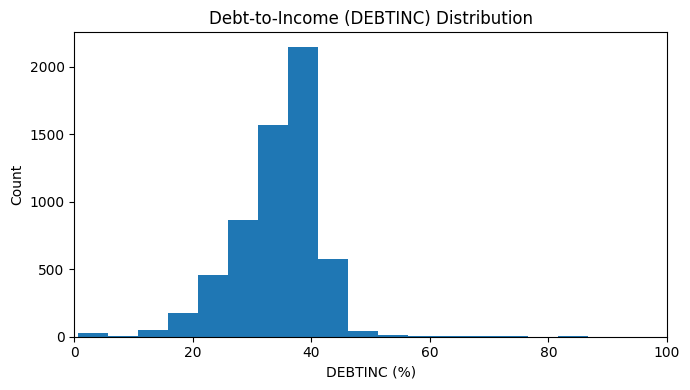

In [20]:
print("\n=== 1) Affordability (DEBTINC) ===")
if 'DEBTINC' in df.columns:
    di = df['DEBTINC'].dropna()
    print("Count:", len(di))
    print(di.describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]))

    plt.figure(figsize=(7,4))
    plt.hist(di, bins=40)
    plt.title('Debt-to-Income (DEBTINC) Distribution')
    plt.xlabel('DEBTINC (%)')
    plt.ylabel('Count')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("DEBTINC not found. Skipping.")


In [4]:
# Separate into good and bad customers
good_customers = df[df['BAD'] == 0]
bad_customers = df[df['BAD'] == 1]

# Check counts
print("Good customers:", good_customers.shape[0])
print("Bad customers:", bad_customers.shape[0])

# Optional: basic summary stats
print("\nSummary of Good Customers:")
print(good_customers.describe())

print("\nSummary of Bad Customers:")
print(bad_customers.describe())

Good customers: 4771
Bad customers: 1189

Summary of Good Customers:
          BAD          LOAN
count  4771.0   4771.000000
mean      0.0  19028.107315
std       0.0  11115.758554
min       0.0   1700.000000
25%       0.0  11700.000000
50%       0.0  16900.000000
75%       0.0  23500.000000
max       0.0  89900.000000

Summary of Bad Customers:
          BAD          LOAN
count  1189.0   1189.000000
mean      1.0  16922.119428
std       0.0  11418.455152
min       1.0   1100.000000
25%       1.0   9200.000000
50%       1.0  14900.000000
75%       1.0  21700.000000
max       1.0  77400.000000


/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

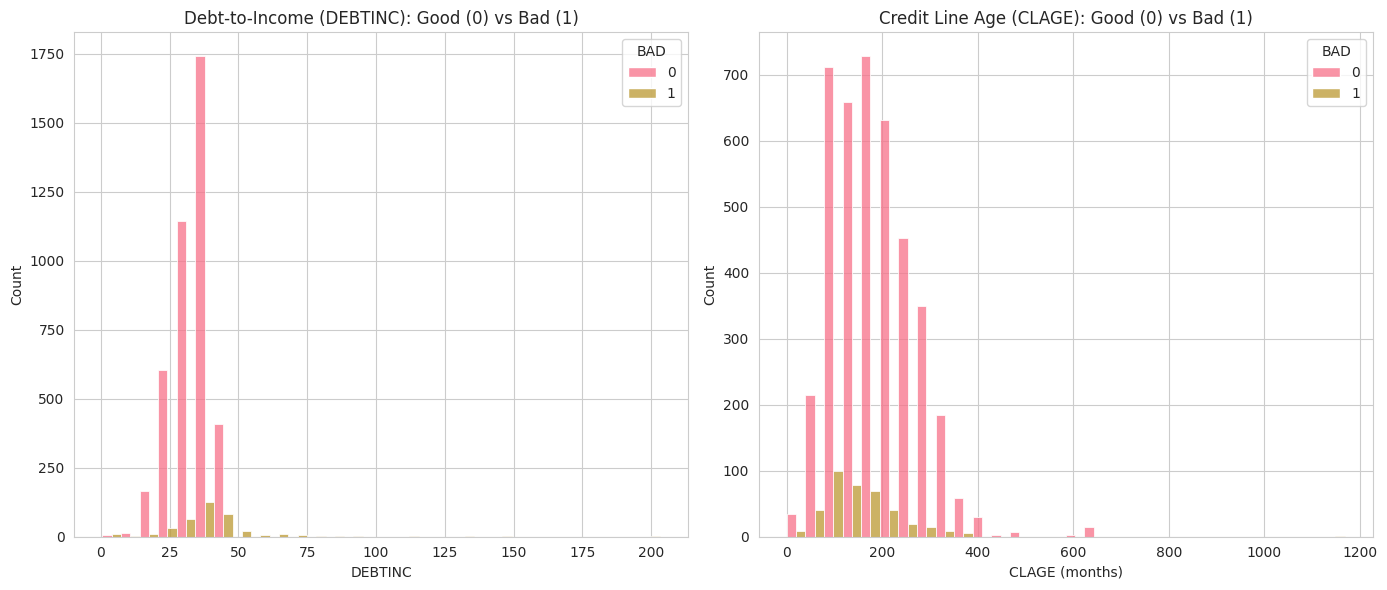

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric (important if there are strings or NaNs)
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')
df['CLAGE']   = pd.to_numeric(df['CLAGE'], errors='coerce')

# Drop NaNs for plotting
plot_df = df[['BAD','DEBTINC','CLAGE']].dropna()

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for DEBTINC
sns.histplot(data=plot_df, x='DEBTINC', hue='BAD', bins=30,
             multiple='dodge', ax=axes[0])
axes[0].set_title("Debt-to-Income (DEBTINC): Good (0) vs Bad (1)")
axes[0].set_xlabel("DEBTINC")
axes[0].set_ylabel("Count")

# Histogram for CLAGE
sns.histplot(data=plot_df, x='CLAGE', hue='BAD', bins=30,
             multiple='dodge', ax=axes[1])
axes[1].set_title("Credit Line Age (CLAGE): Good (0) vs Bad (1)")
axes[1].set_xlabel("CLAGE (months)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()




=== Comparison vs AU Benchmarks ===
Metric                     Good (BAD=0)       Bad (BAD=1)        AU Benchmark (as_of 2025-06)
       DEBTINC (%, median)   35                 38                40                         
Share > DEBTINC stress (%) 0.18               0.43               NaN                         
    CLAGE (months, median)  180                133               150                         


/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

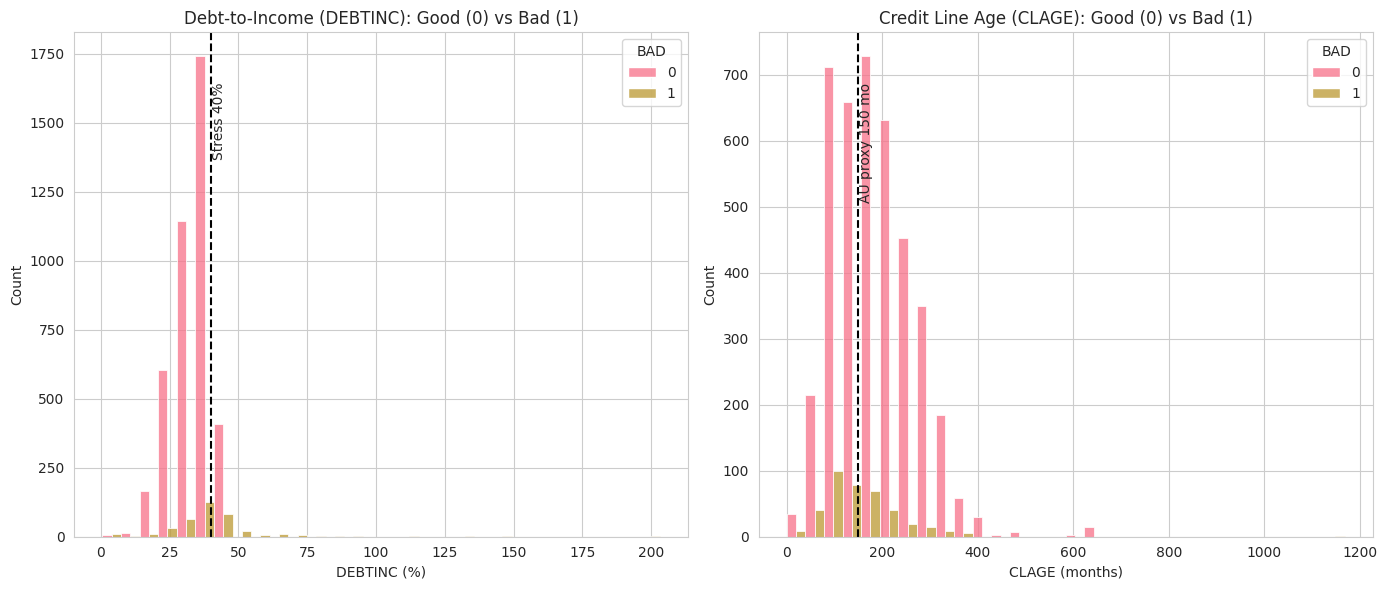


Key takeaways you can paste into slides:
• Share above servicing-stress threshold (40%): Good=17.6%, Bad=42.7%.
• Bad borrowers skew to higher DEBTINC and lower CLAGE; AU regulators flag high servicing burden and thinner credit histories as risk factors in today’s market.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0) CONFIGURE EXTERNAL BENCHMARKS (edit these numbers once) ---
BENCH = {
    "as_of": "2025-06",       # put the month/year of the stats you cite
    "DEBTINC_stress_pct": 40, # % of income for servicing stress (e.g., 40%)
    "DTI_multiple_flag": 6,   # if you also mention DTI>=6x in text; not plotted here
    "CLAGE_benchmark_mo": 150 # optional proxy for typical credit age (months); set to None to skip line
}

# --- 1) BASIC CLEANUP ---
df['BAD'] = pd.to_numeric(df['BAD'], errors='coerce')
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')
df['CLAGE'] = pd.to_numeric(df['CLAGE'], errors='coerce')

plot_df = df[['BAD','DEBTINC','CLAGE']].dropna()

# --- 2) SUMMARY TABLE vs BENCHMARKS ---
def pct_above(series, threshold):
    return float((series > threshold).mean())

good = plot_df[plot_df['BAD']==0]
bad  = plot_df[plot_df['BAD']==1]

rows = []

# DEBTINC summaries
rows.append(["DEBTINC (%, median)", good['DEBTINC'].median(), bad['DEBTINC'].median(), BENCH["DEBTINC_stress_pct"]])
rows.append(["Share > DEBTINC stress (%)",
             pct_above(good['DEBTINC'], BENCH["DEBTINC_stress_pct"]),
             pct_above(bad['DEBTINC'],  BENCH["DEBTINC_stress_pct"]),
             np.nan])

# CLAGE summaries
rows.append(["CLAGE (months, median)", good['CLAGE'].median(), bad['CLAGE'].median(), BENCH["CLAGE_benchmark_mo"]])

summary = pd.DataFrame(rows, columns=["Metric","Good (BAD=0)","Bad (BAD=1)","AU Benchmark (as_of "+BENCH["as_of"]+")"])

# Pretty print
print("\n=== Comparison vs AU Benchmarks ===")
print(summary.to_string(index=False, justify='left', col_space=18, formatters={
    "Good (BAD=0)": lambda x: f"{x:.2f}" if pd.notna(x) and x<=1 else (f"{x:.1%}" if 0<=x<=1 else f"{x:.0f}"),
    "Bad (BAD=1)":  lambda x: f"{x:.2f}" if pd.notna(x) and x<=1 else (f"{x:.1%}" if 0<=x<=1 else f"{x:.0f}"),
    "AU Benchmark (as_of "+BENCH["as_of"]+")": lambda x: "" if pd.isna(x) else (f"{x:.0f}" if x>1 else f"{x:.1%}")
}))

# --- 3) HISTOGRAMS WITH BENCHMARK LINES ---
sns.set_style("whitegrid")
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A) DEBTINC
sns.histplot(data=plot_df, x='DEBTINC', hue='BAD', bins=30, multiple='dodge', ax=axes[0])
axes[0].set_title("Debt-to-Income (DEBTINC): Good (0) vs Bad (1)")
axes[0].set_xlabel("DEBTINC (%)")
axes[0].set_ylabel("Count")

# vertical benchmark line for servicing stress (e.g., 40%)
if BENCH["DEBTINC_stress_pct"] is not None:
    axes[0].axvline(BENCH["DEBTINC_stress_pct"], color='black', linestyle='--', linewidth=1.5)
    axes[0].text(BENCH["DEBTINC_stress_pct"]*1.01, axes[0].get_ylim()[1]*0.9,
                 f"Stress {BENCH['DEBTINC_stress_pct']}%", rotation=90, va='top', ha='left')

# B) CLAGE
sns.histplot(data=plot_df, x='CLAGE', hue='BAD', bins=30, multiple='dodge', ax=axes[1])
axes[1].set_title("Credit Line Age (CLAGE): Good (0) vs Bad (1)")
axes[1].set_xlabel("CLAGE (months)")
axes[1].set_ylabel("Count")

# optional benchmark line for typical credit age
if BENCH["CLAGE_benchmark_mo"] is not None:
    axes[1].axvline(BENCH["CLAGE_benchmark_mo"], color='black', linestyle='--', linewidth=1.5)
    axes[1].text(BENCH["CLAGE_benchmark_mo"]*1.01, axes[1].get_ylim()[1]*0.9,
                 f"AU proxy {BENCH['CLAGE_benchmark_mo']} mo", rotation=90, va='top', ha='left')

plt.tight_layout()
plt.show()

# --- 4) PLAIN LANGUAGE TAKEAWAYS (optional printouts you can quote) ---
g_share_stress = pct_above(good['DEBTINC'], BENCH["DEBTINC_stress_pct"])
b_share_stress = pct_above(bad['DEBTINC'],  BENCH["DEBTINC_stress_pct"])

print("\nKey takeaways you can paste into slides:")
print(f"• Share above servicing-stress threshold ({BENCH['DEBTINC_stress_pct']}%): "
      f"Good={g_share_stress:.1%}, Bad={b_share_stress:.1%}.")
print("• Bad borrowers skew to higher DEBTINC and lower CLAGE; AU regulators flag high servicing burden "
      "and thinner credit histories as risk factors in today’s market.")



=== Comparison vs AU Benchmarks ===
Metric                     Good (BAD=0)       Bad (BAD=1)        AU Benchmark (as_of 2025-06)
       DEBTINC (%, median)   35                 38                40                         
Share > DEBTINC stress (%) 0.18               0.43               NaN                         
    CLAGE (months, median)  180                133               150                         


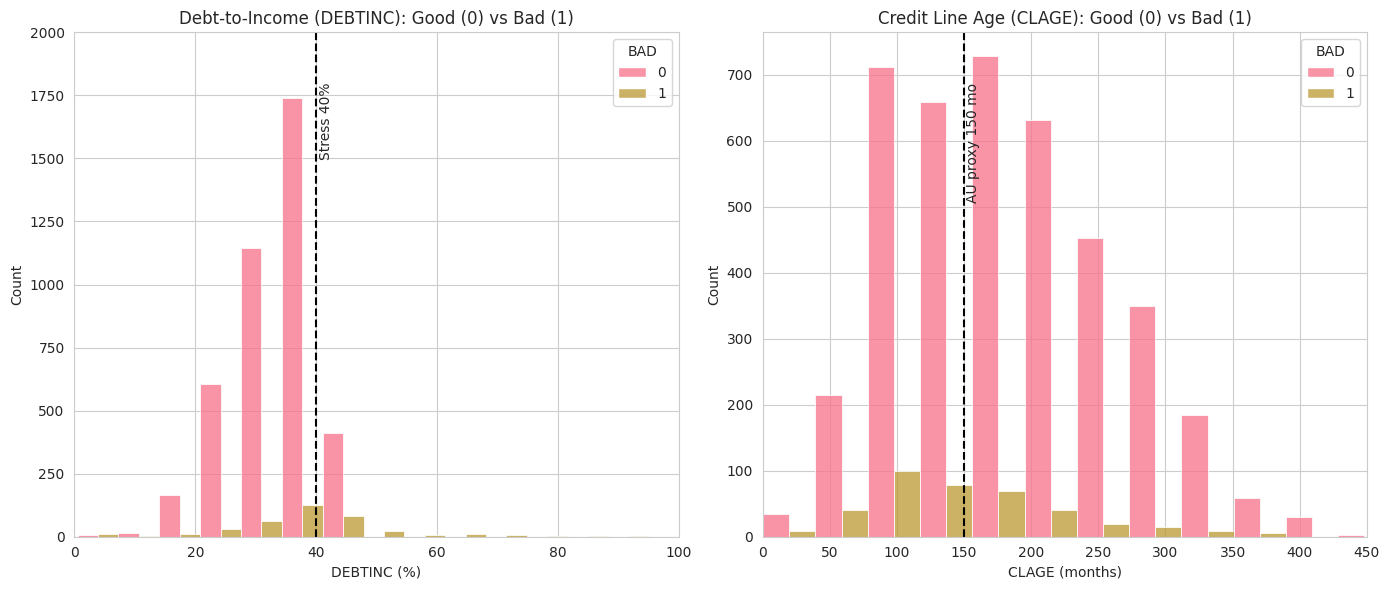

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0) CONFIGURE EXTERNAL BENCHMARKS (edit these numbers once) ---
BENCH = {
    "as_of": "2025-06",
    "DEBTINC_stress_pct": 40,
    "DTI_multiple_flag": 6,
    "CLAGE_benchmark_mo": 150
}

# --- 1) BASIC CLEANUP ---
df['BAD'] = pd.to_numeric(df['BAD'], errors='coerce')
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')
df['CLAGE'] = pd.to_numeric(df['CLAGE'], errors='coerce')

plot_df = df[['BAD','DEBTINC','CLAGE']].dropna()

# --- 2) SUMMARY TABLE vs BENCHMARKS ---
def pct_above(series, threshold):
    return float((series > threshold).mean())

good = plot_df[plot_df['BAD']==0]
bad  = plot_df[plot_df['BAD']==1]

rows = []
rows.append(["DEBTINC (%, median)", good['DEBTINC'].median(), bad['DEBTINC'].median(), BENCH["DEBTINC_stress_pct"]])
rows.append(["Share > DEBTINC stress (%)",
             pct_above(good['DEBTINC'], BENCH["DEBTINC_stress_pct"]),
             pct_above(bad['DEBTINC'],  BENCH["DEBTINC_stress_pct"]),
             np.nan])
rows.append(["CLAGE (months, median)", good['CLAGE'].median(), bad['CLAGE'].median(), BENCH["CLAGE_benchmark_mo"]])

summary = pd.DataFrame(rows, columns=["Metric","Good (BAD=0)","Bad (BAD=1)","AU Benchmark (as_of "+BENCH["as_of"]+")"])

print("\n=== Comparison vs AU Benchmarks ===")
print(summary.to_string(index=False, justify='left', col_space=18, formatters={
    "Good (BAD=0)": lambda x: f"{x:.2f}" if pd.notna(x) and x<=1 else (f"{x:.1%}" if 0<=x<=1 else f"{x:.0f}"),
    "Bad (BAD=1)":  lambda x: f"{x:.2f}" if pd.notna(x) and x<=1 else (f"{x:.1%}" if 0<=x<=1 else f"{x:.0f}"),
    "AU Benchmark (as_of "+BENCH["as_of"]+")": lambda x: "" if pd.isna(x) else (f"{x:.0f}" if x>1 else f"{x:.1%}")
}))

# --- 3) HISTOGRAMS WITH BENCHMARK LINES ---
sns.set_style("whitegrid")
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A) DEBTINC
sns.histplot(data=plot_df, x='DEBTINC', hue='BAD', bins=30, multiple='dodge', ax=axes[0])
axes[0].set_title("Debt-to-Income (DEBTINC): Good (0) vs Bad (1)")
axes[0].set_xlabel("DEBTINC (%)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 100)   # <-- limit x-axis to 0–100
axes[0].set_ylim(0,2000)

if BENCH["DEBTINC_stress_pct"] is not None:
    axes[0].axvline(BENCH["DEBTINC_stress_pct"], color='black', linestyle='--', linewidth=1.5)
    axes[0].text(BENCH["DEBTINC_stress_pct"]*1.01, axes[0].get_ylim()[1]*0.9,
                 f"Stress {BENCH['DEBTINC_stress_pct']}%", rotation=90, va='top', ha='left')

# B) CLAGE
sns.histplot(data=plot_df, x='CLAGE', hue='BAD', bins=30, multiple='dodge', ax=axes[1])
axes[1].set_title("Credit Line Age (CLAGE): Good (0) vs Bad (1)")
axes[1].set_xlabel("CLAGE (months)")
axes[1].set_ylabel("Count")
axes[1].set_xlim(0, 450)   # <-- limit x-axis to 0–100 (remove if you don't want this)

if BENCH["CLAGE_benchmark_mo"] is not None:
    axes[1].axvline(BENCH["CLAGE_benchmark_mo"], color='black', linestyle='--', linewidth=1.5)
    axes[1].text(BENCH["CLAGE_benchmark_mo"]*1.01, axes[1].get_ylim()[1]*0.9,
                 f"AU proxy {BENCH['CLAGE_benchmark_mo']} mo", rotation=90, va='top', ha='left')

plt.tight_layout()
plt.show()



=== Comparison vs AU Benchmarks ===
Metric                                   Good (BAD=0)       Bad (BAD=1)        AU Benchmark (as_of 2025-06)
                     DEBTINC (%, median)   35                 38                40                         
              Share > DEBTINC stress (%) 0.18               0.43               NaN                         
Share > Non-conforming (illustrative, %) 0.00               0.12               NaN                         
                  CLAGE (months, median)  180                133               150                         


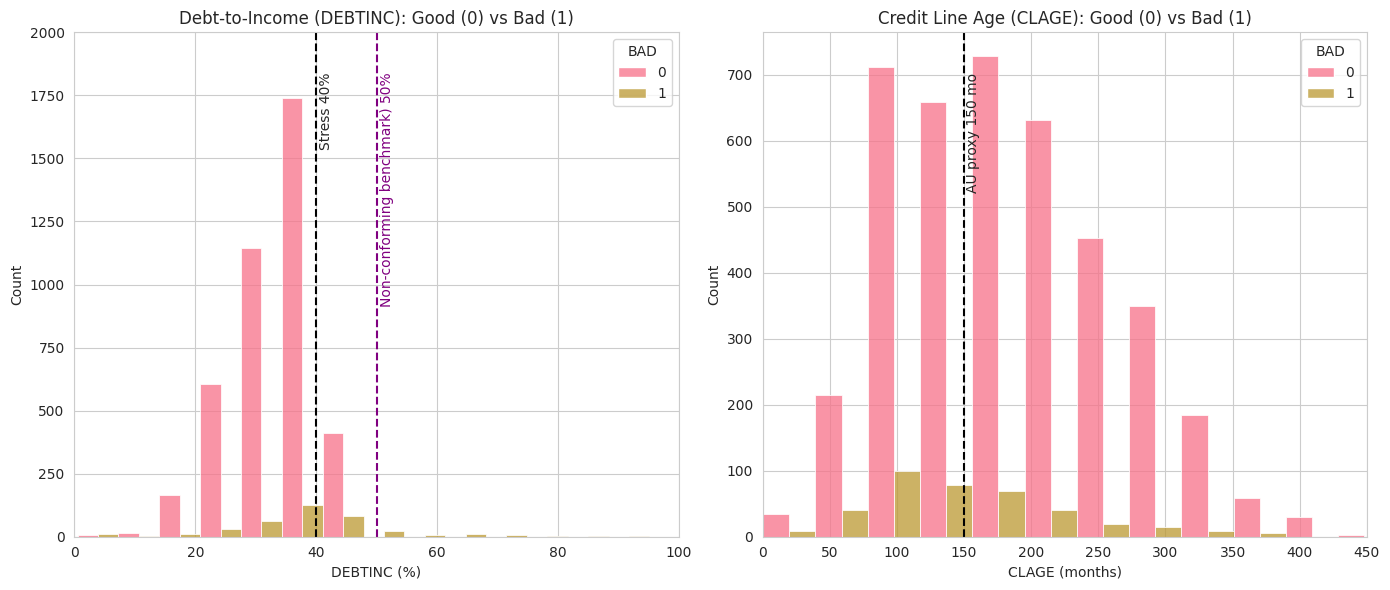

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0) CONFIGURE EXTERNAL BENCHMARKS ---
BENCH = {
    "as_of": "2025-06",
    "DEBTINC_stress_pct": 40,   # conforming/analyst stress marker (see notes)
    "DEBTINC_nonconf_pct": 50,  # illustrative non-conforming stress marker (varies by lender)
    "DTI_multiple_flag": 6,     # RBA/APRA high DTI focus (>=6x)
    "CLAGE_benchmark_mo": 150
}

# --- 1) BASIC CLEANUP ---
df['BAD'] = pd.to_numeric(df['BAD'], errors='coerce')
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')
df['CLAGE'] = pd.to_numeric(df['CLAGE'], errors='coerce')
plot_df = df[['BAD','DEBTINC','CLAGE']].dropna()

# --- 2) SUMMARY TABLE vs BENCHMARKS ---
def pct_above(series, threshold):
    return float((series > threshold).mean())

good = plot_df[plot_df['BAD']==0]
bad  = plot_df[plot_df['BAD']==1]

rows = []
rows.append(["DEBTINC (%, median)", good['DEBTINC'].median(), bad['DEBTINC'].median(), BENCH["DEBTINC_stress_pct"]])
rows.append(["Share > DEBTINC stress (%)",
             pct_above(good['DEBTINC'], BENCH["DEBTINC_stress_pct"]),
             pct_above(bad['DEBTINC'],  BENCH["DEBTINC_stress_pct"]),
             np.nan])
rows.append(["Share > Non-conforming (illustrative, %)",
             pct_above(good['DEBTINC'], BENCH["DEBTINC_nonconf_pct"]),
             pct_above(bad['DEBTINC'],  BENCH["DEBTINC_nonconf_pct"]),
             np.nan])
rows.append(["CLAGE (months, median)", good['CLAGE'].median(), bad['CLAGE'].median(), BENCH["CLAGE_benchmark_mo"]])

summary = pd.DataFrame(rows, columns=["Metric","Good (BAD=0)","Bad (BAD=1)","AU Benchmark (as_of "+BENCH["as_of"]+")"])

print("\n=== Comparison vs AU Benchmarks ===")
print(summary.to_string(index=False, justify='left', col_space=18, formatters={
    "Good (BAD=0)": lambda x: f"{x:.2f}" if pd.notna(x) and x<=1 else (f"{x:.1%}" if 0<=x<=1 else f"{x:.0f}"),
    "Bad (BAD=1)":  lambda x: f"{x:.2f}" if pd.notna(x) and x<=1 else (f"{x:.1%}" if 0<=x<=1 else f"{x:.0f}"),
    "AU Benchmark (as_of "+BENCH["as_of"]+")": lambda x: "" if pd.isna(x) else (f"{x:.0f}" if x>1 else f"{x:.1%}")
}))

# --- 3) HISTOGRAMS WITH BENCHMARK LINES ---
sns.set_style("whitegrid")
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A) DEBTINC
sns.histplot(data=plot_df, x='DEBTINC', hue='BAD', bins=30, multiple='dodge', ax=axes[0])
axes[0].set_title("Debt-to-Income (DEBTINC): Good (0) vs Bad (1)")
axes[0].set_xlabel("DEBTINC (%)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 2000)

# conforming stress marker (analyst convention)
axes[0].axvline(BENCH["DEBTINC_stress_pct"], color='black', linestyle='--', linewidth=1.5)
axes[0].text(BENCH["DEBTINC_stress_pct"]*1.01, axes[0].get_ylim()[1]*0.92,
             f"Stress {BENCH['DEBTINC_stress_pct']}%", rotation=90, va='top', ha='left')

# non-conforming illustrative marker
axes[0].axvline(BENCH["DEBTINC_nonconf_pct"], color='purple', linestyle='--', linewidth=1.5)
axes[0].text(BENCH["DEBTINC_nonconf_pct"]*1.01, axes[0].get_ylim()[1]*0.92,
             f"Non-conforming (benchmark) {BENCH['DEBTINC_nonconf_pct']}%", rotation=90, va='top', ha='left', color='purple')

# B) CLAGE
sns.histplot(data=plot_df, x='CLAGE', hue='BAD', bins=30, multiple='dodge', ax=axes[1])
axes[1].set_title("Credit Line Age (CLAGE): Good (0) vs Bad (1)")
axes[1].set_xlabel("CLAGE (months)")
axes[1].set_ylabel("Count")
axes[1].set_xlim(0, 450)

axes[1].axvline(BENCH["CLAGE_benchmark_mo"], color='black', linestyle='--', linewidth=1.5)
axes[1].text(BENCH["CLAGE_benchmark_mo"]*1.01, axes[1].get_ylim()[1]*0.92,
             f"AU proxy {BENCH['CLAGE_benchmark_mo']} mo", rotation=90, va='top', ha='left')

plt.tight_layout()
plt.show()


In [4]:
# --- Default Rate by Profession & Loan Analysis ---

# Group by profession (JOB)
prof_summary = (
    df.groupby("JOB")
    .agg(
        total_loans=("BAD", "size"),
        default_rate=("BAD", "mean"),     # share of BAD=1 (defaults)
        median_loan=("LOAN", "median"),
        avg_loan=("LOAN", "mean")
    )
    .reset_index()
    .sort_values("default_rate", ascending=False)
)

# Pretty formatting for display
prof_summary_display = prof_summary.copy()
prof_summary_display["default_rate"] = prof_summary_display["default_rate"].apply(lambda x: f"{x:.1%}")
prof_summary_display["median_loan"]  = prof_summary_display["median_loan"].apply(lambda x: f"${x:,.0f}")
prof_summary_display["avg_loan"]     = prof_summary_display["avg_loan"].apply(lambda x: f"${x:,.0f}")

display(prof_summary_display)

# Optional: Save to CSV for reporting
prof_summary.to_csv("default_rate_by_profession.csv", index=False)
print("✅ Default rate by profession with loan sizes saved to default_rate_by_profession.csv")


,JOB,total_loans,default_rate,median_loan,avg_loan
4,Sales,109,34.9%,"$14,300","$14,914"
5,Self,193,30.1%,"$24,000","$28,315"
0,Mgr,767,23.3%,"$18,100","$19,155"
2,Other,2388,23.2%,"$15,650","$18,062"
3,ProfExe,1276,16.6%,"$17,300","$18,983"
1,Office,948,13.2%,"$16,200","$18,143"


✅ Default rate by profession with loan sizes saved to default_rate_by_profession.csv


,Profession,Default rate,Median loan,Count,vs APRA 1.0%,vs Fitch 1.36%,vs Non-conf 5.32%,vs Hist. 1.86%
4,Sales,34.9%,"$14,300",109,>↑,>↑,>↑,>↑
5,Self,30.1%,"$24,000",193,>↑,>↑,>↑,>↑
0,Mgr,23.3%,"$18,100",767,>↑,>↑,>↑,>↑
2,Other,23.2%,"$15,650",2388,>↑,>↑,>↑,>↑
3,ProfExe,16.6%,"$17,300",1276,>↑,>↑,>↑,>↑
1,Office,13.2%,"$16,200",948,>↑,>↑,>↑,>↑


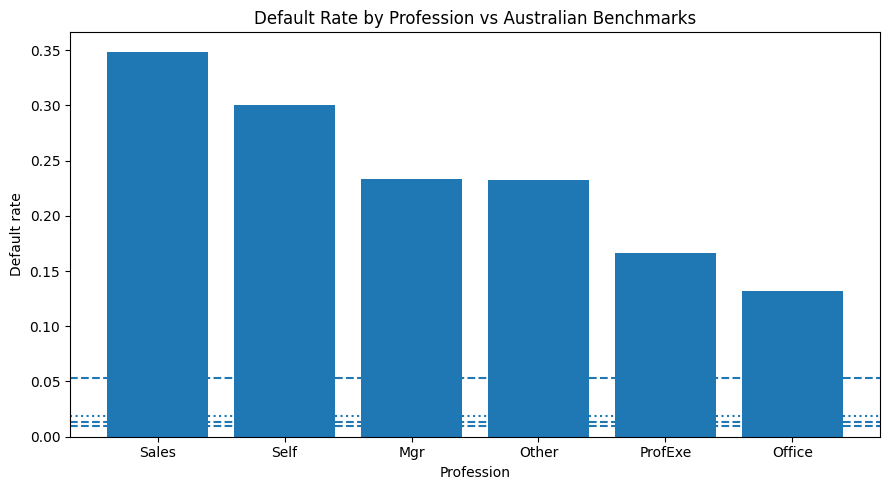

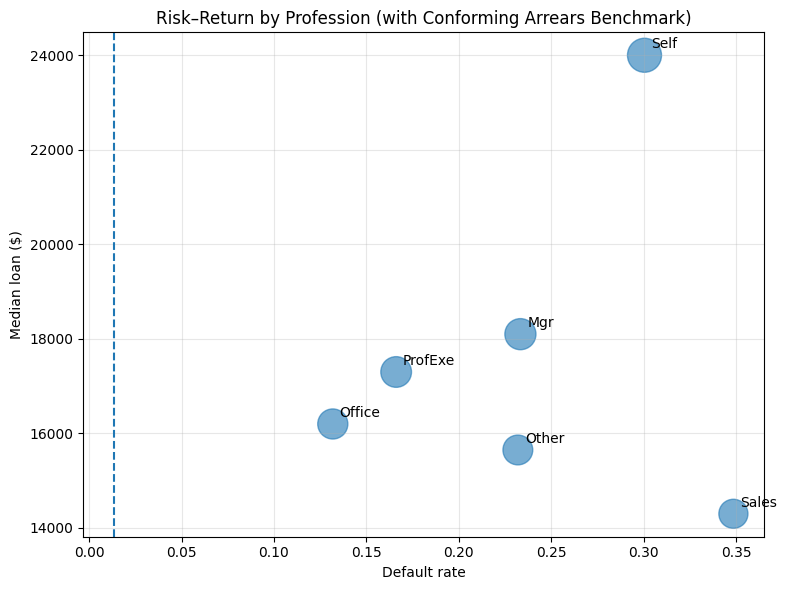


Key Benchmarks used:
- APRA NPL (overall resi): 1.00%
- Fitch 30+ DPD (conforming): 1.36%
- Fitch 30+ DPD (non-conforming): 5.32%
- Historical peak reference: 1.86%

Segment classification vs market:
- Higher than NON-CONFORMING benchmark (very high risk): ['Sales', 'Self', 'Mgr', 'Other', 'ProfExe', 'Office']
- Between conforming and non-conforming (elevated risk): []
- At/Below conforming arrears benchmark (closer to market): []


In [4]:
# --- Benchmarked Default/Arrears Comparison (Australia) ----------------------
# Assumes you already have a cleaned DataFrame `df` with columns: JOB, BAD, LOAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Benchmarks (edit if you update sources)
BENCH = {
    "APRA_NPL_overall": 0.010,      # ~1.0% non-performing share (APRA, resi mortgages)
    "Fitch_30dpd_conforming": 0.0136,  # 1.36% 30+ DPD arrears (Q1 2025)
    "Fitch_30dpd_nonconf": 0.0532,     # 5.32% 30+ DPD arrears (non-conforming, Q1 2025)
    "Historical_peak": 0.0186        # ~1.86% historical peak reference
}
# Notes (for your report):
# - APRA: Quarterly ADI Property Exposure (NPL shares)
# - RBA: Bulletin on recent drivers of arrears (trend context)
# - Fitch: 30+ DPD arrears for conforming & non-conforming RMBS

# 2) Your portfolio: default rate by profession & loan size
seg = (
    df.groupby("JOB")
      .agg(default_rate=("BAD","mean"),
           median_loan=("LOAN","median"),
           n=("BAD","size"))
      .reset_index()
      .sort_values("default_rate", ascending=False)
)

# 3) Summary table vs benchmarks
def flag(level, ref):
    return ">\u2191" if level > ref else "\u2264"

summary = seg.copy()
summary["vs_APRA_NPL"]   = summary["default_rate"].apply(lambda x: flag(x, BENCH["APRA_NPL_overall"]))
summary["vs_Fitch_conf"] = summary["default_rate"].apply(lambda x: flag(x, BENCH["Fitch_30dpd_conforming"]))
summary["vs_Fitch_non"]  = summary["default_rate"].apply(lambda x: flag(x, BENCH["Fitch_30dpd_nonconf"]))
summary["vs_hist_peak"]  = summary["default_rate"].apply(lambda x: flag(x, BENCH["Historical_peak"]))

# Pretty display copy
disp = summary.copy()
disp["default_rate"] = disp["default_rate"].map(lambda x: f"{x:.1%}")
disp["median_loan"]  = disp["median_loan"].map(lambda x: f"${x:,.0f}")
disp.rename(columns={
    "JOB":"Profession", "n":"Count",
    "default_rate":"Default rate",
    "median_loan":"Median loan",
    "vs_APRA_NPL":"vs APRA 1.0%",
    "vs_Fitch_conf":"vs Fitch 1.36%",
    "vs_Fitch_non":"vs Non-conf 5.32%",
    "vs_hist_peak":"vs Hist. 1.86%"
}, inplace=True)

display(disp)

# 4) Chart A: Default rate by profession with benchmark lines
plt.figure(figsize=(9,5))
plt.bar(summary["JOB"], summary["default_rate"])
plt.axhline(BENCH["APRA_NPL_overall"], linestyle="--")
plt.axhline(BENCH["Fitch_30dpd_conforming"], linestyle="--")
plt.axhline(BENCH["Fitch_30dpd_nonconf"], linestyle="--")
plt.axhline(BENCH["Historical_peak"], linestyle=":")
plt.title("Default Rate by Profession vs Australian Benchmarks")
plt.ylabel("Default rate")
plt.xlabel("Profession")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5) Chart B: Risk–Return bubble with benchmark marker
sizes = 400 * (summary["median_loan"] / summary["median_loan"].max()) + 200
plt.figure(figsize=(8,6))
plt.scatter(summary["default_rate"], summary["median_loan"], s=sizes, alpha=0.6)
for _, r in summary.iterrows():
    plt.annotate(r["JOB"], (r["default_rate"], r["median_loan"]), xytext=(5,5), textcoords="offset points")
# Bench reference line (conforming arrears)
plt.axvline(BENCH["Fitch_30dpd_conforming"], linestyle="--")
plt.title("Risk–Return by Profession (with Conforming Arrears Benchmark)")
plt.xlabel("Default rate")
plt.ylabel("Median loan ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6) Quick text takeaways you can print in your report
def p(x): return f"{100*x:.2f}%"
print("\nKey Benchmarks used:")
print(f"- APRA NPL (overall resi): {p(BENCH['APRA_NPL_overall'])}")
print(f"- Fitch 30+ DPD (conforming): {p(BENCH['Fitch_30dpd_conforming'])}")
print(f"- Fitch 30+ DPD (non-conforming): {p(BENCH['Fitch_30dpd_nonconf'])}")
print(f"- Historical peak reference: {p(BENCH['Historical_peak'])}")

high = summary[summary["default_rate"] > BENCH["Fitch_30dpd_nonconf"]]["JOB"].tolist()
mid  = summary[(summary["default_rate"] > BENCH["Fitch_30dpd_conforming"]) &
               (summary["default_rate"] <= BENCH["Fitch_30dpd_nonconf"])]["JOB"].tolist()
low  = summary[summary["default_rate"] <= BENCH["Fitch_30dpd_conforming"]]["JOB"].tolist()

print("\nSegment classification vs market:")
print(f"- Higher than NON-CONFORMING benchmark (very high risk): {high}")
print(f"- Between conforming and non-conforming (elevated risk): {mid}")
print(f"- At/Below conforming arrears benchmark (closer to market): {low}")


/tmp/ipykernel_95/2126124107.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['DELINQ_Bucket', 'BAD'])


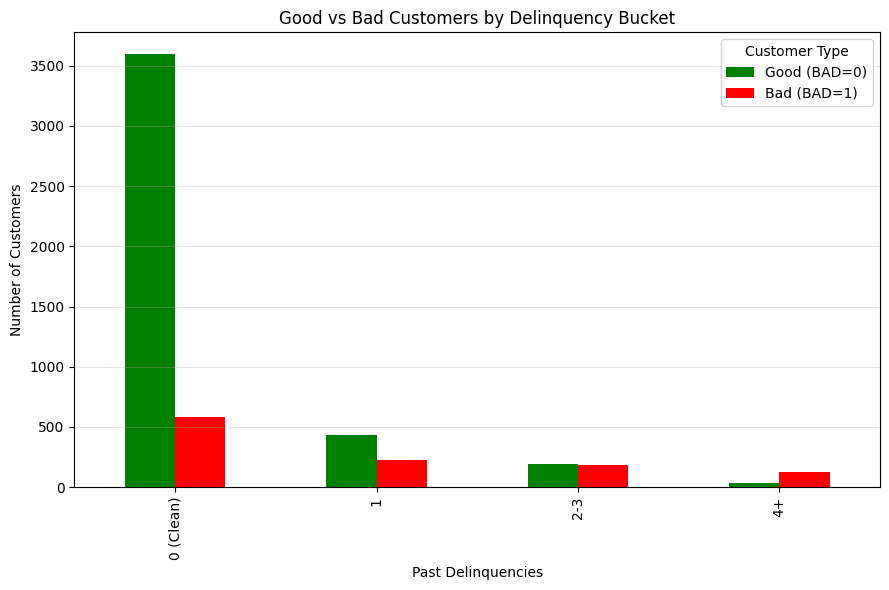

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Ensure DELINQ numeric
df['DELINQ'] = pd.to_numeric(df['DELINQ'], errors='coerce')

# 2) Create DELINQ buckets
df['DELINQ_Bucket'] = pd.cut(
    df['DELINQ'],
    bins=[-1, 0, 1, 3, 20],
    labels=["0 (Clean)", "1", "2-3", "4+"]
)

# 3) Group by delinquency bucket and BAD (0=Good, 1=Bad)
delinq_split = (
    df.groupby(['DELINQ_Bucket', 'BAD'])
      .size()
      .reset_index(name='count')
)

# 4) Pivot for stacked bar (Good vs Bad counts per bucket)
delinq_pivot = delinq_split.pivot(index='DELINQ_Bucket', columns='BAD', values='count').fillna(0)
delinq_pivot = delinq_pivot.rename(columns={0: 'Good (BAD=0)', 1: 'Bad (BAD=1)'})

# 5) Plot stacked bar
delinq_pivot.plot(kind='bar', stacked=False, figsize=(9,6), color=['green', 'red'])

plt.title("Good vs Bad Customers by Delinquency Bucket")
plt.xlabel("Past Delinquencies")
plt.ylabel("Number of Customers")
plt.legend(title="Customer Type")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



/tmp/ipykernel_95/2710935550.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['DELINQ_Bucket', 'BAD'])


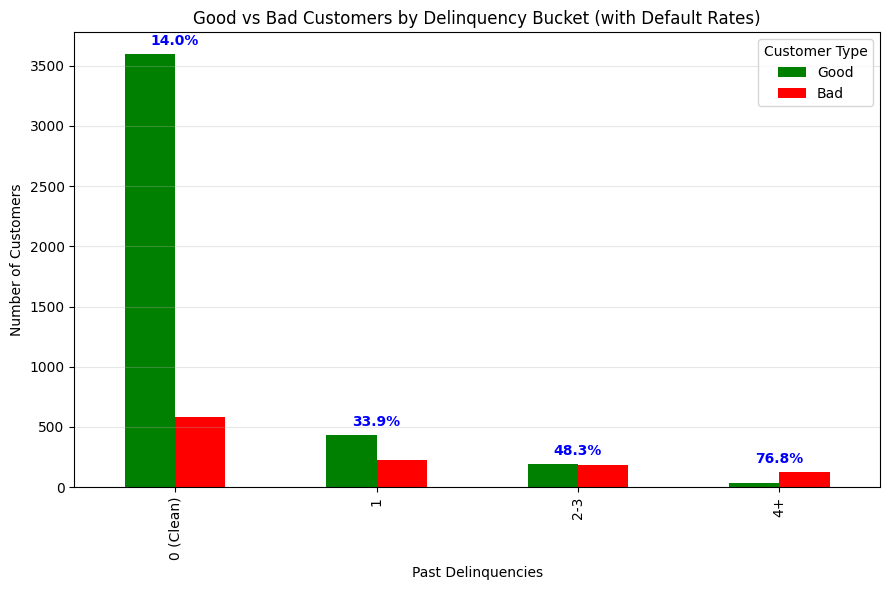

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Ensure DELINQ numeric
df['DELINQ'] = pd.to_numeric(df['DELINQ'], errors='coerce')

# 2) Create delinquency buckets
df['DELINQ_Bucket'] = pd.cut(
    df['DELINQ'],
    bins=[-1, 0, 1, 3, 20],
    labels=["0 (Clean)", "1", "2-3", "4+"]
)

# 3) Group counts by Good/Bad
delinq_split = (
    df.groupby(['DELINQ_Bucket', 'BAD'])
      .size()
      .reset_index(name='count')
)

# 4) Pivot for bar chart
delinq_pivot = delinq_split.pivot(index='DELINQ_Bucket', columns='BAD', values='count').fillna(0)
delinq_pivot = delinq_pivot.rename(columns={0: 'Good', 1: 'Bad'})

# 5) Compute default rate per bucket
delinq_pivot['Default_Rate'] = delinq_pivot['Bad'] / (delinq_pivot['Good'] + delinq_pivot['Bad'])

# 6) Plot side-by-side Good vs Bad
ax = delinq_pivot[['Good', 'Bad']].plot(
    kind='bar',
    figsize=(9,6),
    color=['green','red']
)

# Add labels for default rate on top of each bucket
for idx, rate in enumerate(delinq_pivot['Default_Rate']):
    ax.text(idx, 
            delinq_pivot[['Good','Bad']].iloc[idx].max() + 50,   # place slightly above highest bar
            f"{rate:.1%}", 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color="blue")

plt.title("Good vs Bad Customers by Delinquency Bucket (with Default Rates)")
plt.xlabel("Past Delinquencies")
plt.ylabel("Number of Customers")
plt.legend(title="Customer Type")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_116/2135911872.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (df.groupby(['DELINQ_Bucket','BAD'])


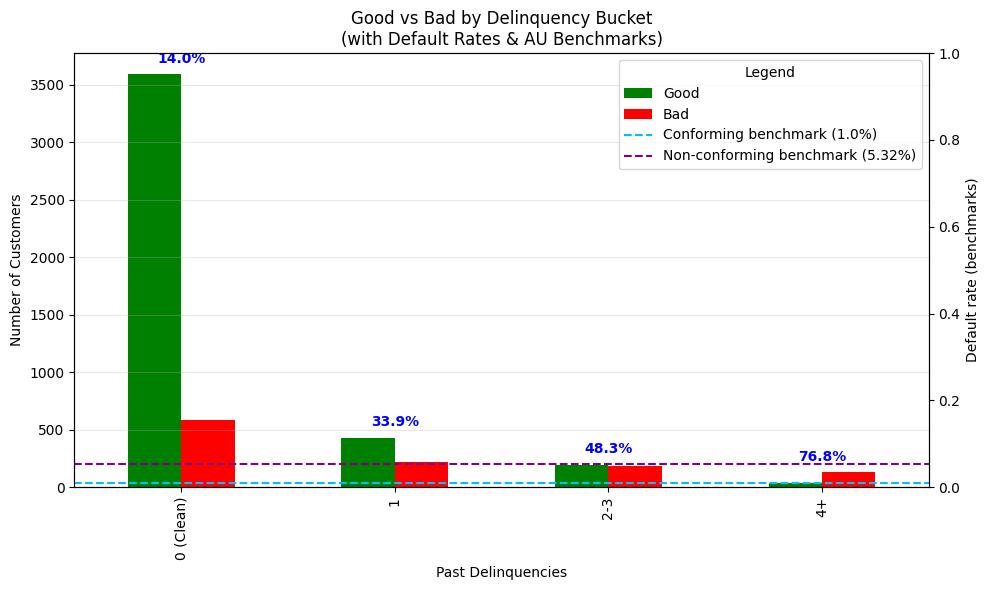

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Prep buckets ---
df['DELINQ'] = pd.to_numeric(df['DELINQ'], errors='coerce')
df['DELINQ_Bucket'] = pd.cut(
    df['DELINQ'],
    bins=[-1, 0, 1, 3, 20],
    labels=["0 (Clean)", "1", "2-3", "4+"]
)

# --- Counts & default rate ---
counts = (df.groupby(['DELINQ_Bucket','BAD'])
            .size().reset_index(name='count'))

pivot = counts.pivot(index='DELINQ_Bucket', columns='BAD', values='count').fillna(0)
pivot = pivot.rename(columns={0:'Good', 1:'Bad'}).sort_index()
pivot['Default_Rate'] = pivot['Bad'] / (pivot['Good'] + pivot['Bad'])

# --- Benchmarks ---
BENCH_CONFORMING = 0.01     # ~1% arrears (prime/conforming)
BENCH_NONCONF    = 0.0532   # 5.32% arrears (non-conforming, Fitch)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,6))

# Bars = counts
pivot[['Good','Bad']].plot(kind='bar', ax=ax, color=['green','red'])
ax.set_title("Good vs Bad by Delinquency Bucket\n(with Default Rates & AU Benchmarks)")
ax.set_xlabel("Past Delinquencies")
ax.set_ylabel("Number of Customers")
ax.grid(axis='y', alpha=0.3)

# Annotate default rate (%) above each bucket
for i, rate in enumerate(pivot['Default_Rate']):
    top = pivot[['Good','Bad']].iloc[i].max()
    ax.text(i, top + max(pivot[['Good','Bad']].to_numpy().ravel())*0.02,
            f"{rate:.1%}", ha='center', va='bottom', fontsize=10, color='blue', fontweight='bold')

# Secondary Y-axis for benchmark % lines
ax2 = ax.twinx()
ax2.set_ylim(0, 1.0)                 # 0% to 100%
ax2.set_ylabel("Default rate (benchmarks)")
h1, l1 = ax.get_legend_handles_labels()

# Draw benchmark lines on the % axis
line1 = ax2.axhline(BENCH_CONFORMING, color='deepskyblue', linestyle='--', linewidth=1.5,
                    label=f"Conforming benchmark ({BENCH_CONFORMING*100:.1f}%)")
line2 = ax2.axhline(BENCH_NONCONF, color='purple', linestyle='--', linewidth=1.5,
                    label=f"Non-conforming benchmark ({BENCH_NONCONF*100:.2f}%)")

# Combine legends from both axes
h2, l2 = [line1, line2], [line1.get_label(), line2.get_label()]
ax.legend(h1+h2, l1+l2, title="Legend", loc='upper right')

plt.tight_layout()
plt.show()


/tmp/ipykernel_52/2818839614.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("LTV_Bucket")['BAD']


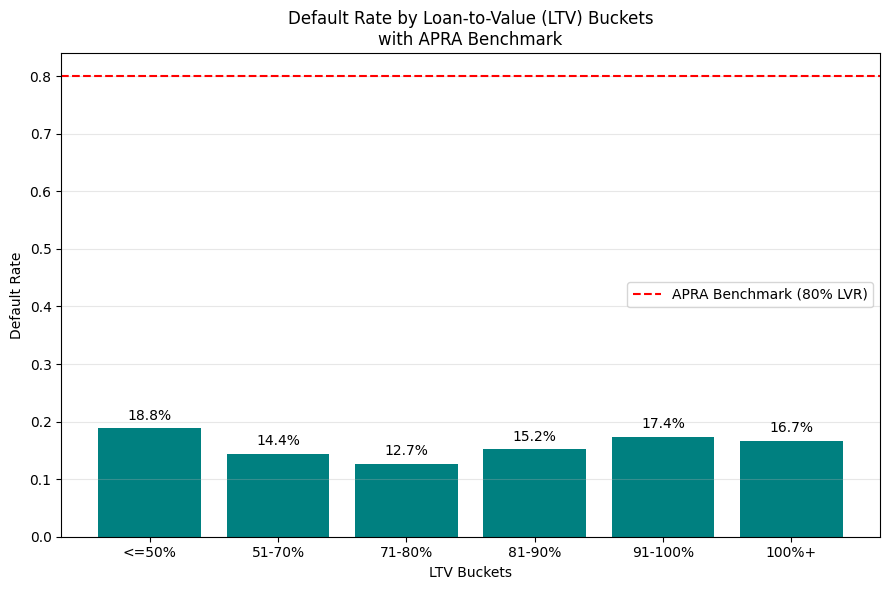

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Calculate Loan-to-Value ratio
df['LOAN'] = pd.to_numeric(df['LOAN'], errors='coerce')
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')
df['LTV'] = df['LOAN'] / df['VALUE']

# 2) APRA Benchmark threshold
APRA_LVR_THRESHOLD = 0.80   # 80%

# 3) Bucket LTV values
df['LTV_Bucket'] = pd.cut(
    df['LTV'],
    bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0, 5.0],   # up to 500% for outliers
    labels=["<=50%", "51-70%", "71-80%", "81-90%", "91-100%", "100%+"]
)

# 4) Default rate by LTV bucket
ltv_summary = (
    df.groupby("LTV_Bucket")['BAD']
      .mean()
      .reset_index()
      .rename(columns={'BAD':'default_rate'})
)

# 5) Plot Default Rates
plt.figure(figsize=(9,6))
bars = plt.bar(ltv_summary['LTV_Bucket'], ltv_summary['default_rate'], color="teal")

# Add threshold line
plt.axhline(y=APRA_LVR_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
            label=f"APRA Benchmark (80% LVR)")

# Labels
plt.title("Default Rate by Loan-to-Value (LTV) Buckets\nwith APRA Benchmark")
plt.ylabel("Default Rate")
plt.xlabel("LTV Buckets")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Annotate values above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.01,
             f"{yval:.1%}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


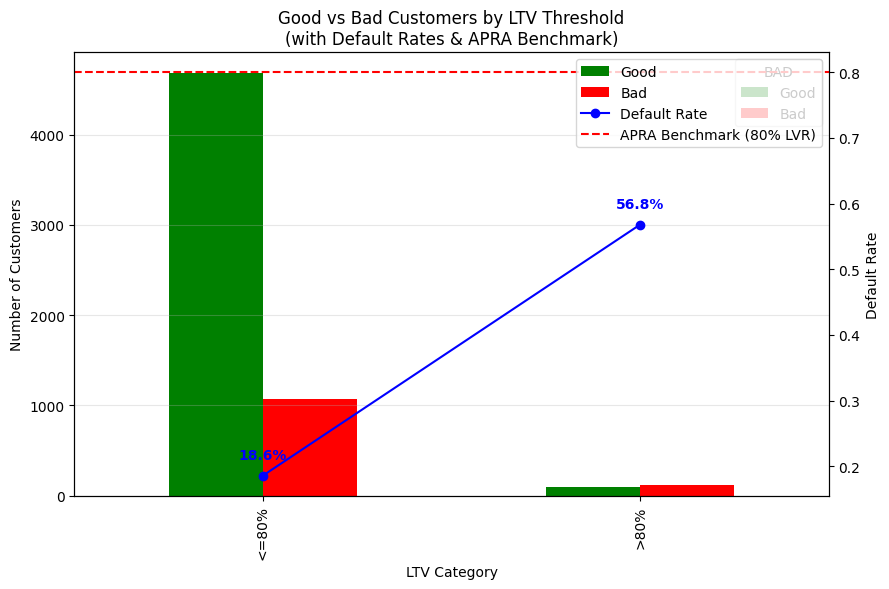

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Calculate LTV ---
df['LOAN']  = pd.to_numeric(df['LOAN'], errors='coerce')
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')
df['LTV']   = df['LOAN'] / df['VALUE']

# --- Bucket into <=80% vs >80% ---
df['LTV_Category'] = df['LTV'].apply(lambda x: '<=80%' if x <= 0.80 else '>80%')

# --- Good/Bad counts and default rate ---
ltv_counts = (df.groupby(['LTV_Category','BAD']).size()
                .reset_index(name='count'))
pivot = (ltv_counts.pivot(index='LTV_Category', columns='BAD', values='count')
                    .fillna(0).rename(columns={0:'Good', 1:'Bad'}).reset_index())
pivot = pivot.sort_values('LTV_Category')

pivot['Total']        = pivot['Good'] + pivot['Bad']
pivot['Default_Rate'] = pivot['Bad'] / pivot['Total']

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(9,6))

# Bar chart (Good vs Bad customers)
pivot.plot(x='LTV_Category', y=['Good','Bad'], kind='bar',
           stacked=False, color=['green','red'], ax=ax1)

ax1.set_title("Good vs Bad Customers by LTV Threshold\n(with Default Rates & APRA Benchmark)")
ax1.set_xlabel("LTV Category")
ax1.set_ylabel("Number of Customers")
ax1.grid(axis='y', alpha=0.3)

# --- Secondary axis for default rate ---
ax2 = ax1.twinx()
ax2.set_ylabel("Default Rate")

# Plot default rate points/line
ax2.plot(pivot['LTV_Category'], pivot['Default_Rate'], marker='o', color='blue', label="Default Rate")

# Annotate default rates
for i, r in pivot.iterrows():
    ax2.text(i, r['Default_Rate'] + 0.02, f"{r['Default_Rate']:.1%}",
             ha='center', va='bottom', color='blue', fontweight='bold')

# --- APRA threshold line on default rate axis (80% LVR ≈ 0.80) ---
APRA_THRESHOLD = 0.80
ax2.axhline(y=APRA_THRESHOLD, color='red', linestyle='--',
            label="APRA Benchmark (80% LVR)")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()




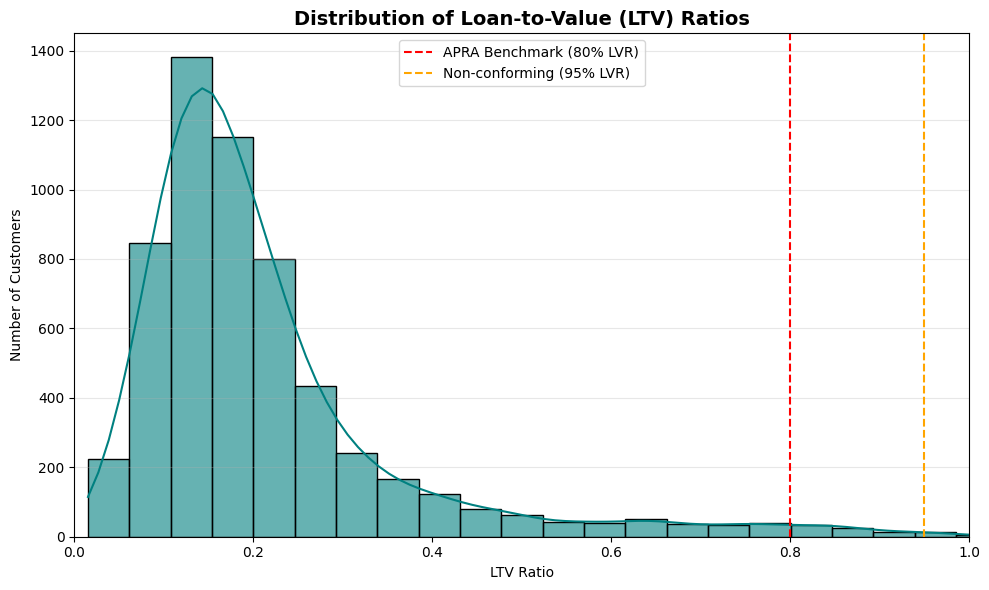

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure LOAN and VALUE are numeric
df['LOAN']  = pd.to_numeric(df['LOAN'], errors='coerce')
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')

# Calculate LTV
df['LTV'] = df['LOAN'] / df['VALUE']

# Drop missing or infinite values
ltv_clean = df['LTV'].replace([float('inf'), -float('inf')], pd.NA).dropna()

# --- Plot distribution ---
plt.figure(figsize=(10,6))

# Histogram + KDE
sns.histplot(ltv_clean, bins=50, kde=True, color="teal", alpha=0.6)

# Add APRA 80% benchmark line
plt.axvline(0.8, color="red", linestyle="--", linewidth=1.5, label="APRA Benchmark (80% LVR)")

# Add Non-conforming 95% benchmark line
plt.axvline(0.95, color="orange", linestyle="--", linewidth=1.5, label="Non-conforming (95% LVR)")

# Limit x-axis to 1.0 (100%)
plt.xlim(0, 1.0)

plt.title("Distribution of Loan-to-Value (LTV) Ratios", fontsize=14, fontweight='bold')
plt.xlabel("LTV Ratio")
plt.ylabel("Number of Customers")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



/tmp/ipykernel_92/3430169524.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("NINQ_Bucket")['BAD']
/tmp/ipykernel_92/3430169524.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("DEROG_Bucket")['BAD']


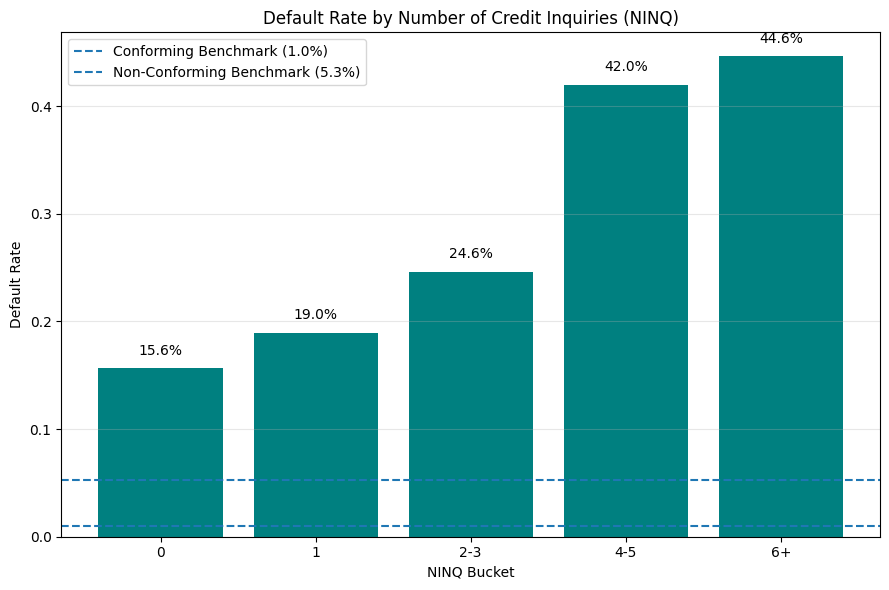

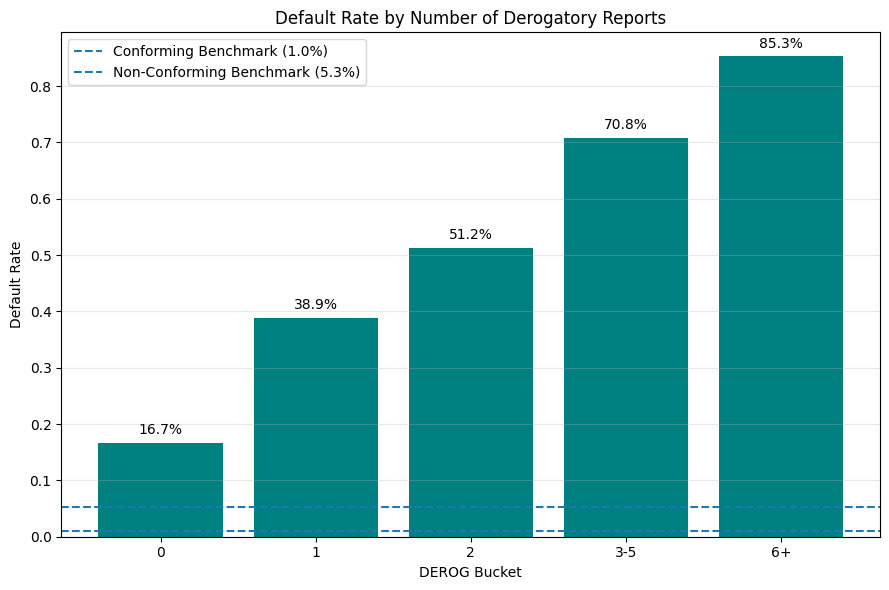

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Convert NINQ and DEROG to numeric ---
df['NINQ'] = pd.to_numeric(df['NINQ'], errors='coerce')
df['DEROG'] = pd.to_numeric(df['DEROG'], errors='coerce')
df['BAD'] = pd.to_numeric(df['BAD'], errors='coerce')

# --- 2) Benchmarks ---
BENCHMARKS = {
    "Conforming": 0.01,   # ~1% default rate
    "Non-Conforming": 0.053  # ~5.3% default rate
}

# --- 3) Bucket NINQ ---
df['NINQ_Bucket'] = pd.cut(
    df['NINQ'],
    bins=[-1,0,1,3,5,20],
    labels=["0", "1", "2-3", "4-5", "6+"]
)

ninq_summary = (
    df.groupby("NINQ_Bucket")['BAD']
      .mean()
      .reset_index()
      .rename(columns={'BAD':'default_rate'})
)

# --- 4) Bucket DEROG ---
df['DEROG_Bucket'] = pd.cut(
    df['DEROG'],
    bins=[-1,0,1,2,5,20],
    labels=["0", "1", "2", "3-5", "6+"]
)

derog_summary = (
    df.groupby("DEROG_Bucket")['BAD']
      .mean()
      .reset_index()
      .rename(columns={'BAD':'default_rate'})
)

# --- 5) Plot function ---
def plot_with_benchmarks(summary, bucket_col, title):
    plt.figure(figsize=(9,6))
    bars = plt.bar(summary[bucket_col], summary['default_rate'], color="teal")

    # Add benchmarks as horizontal lines
    for label, value in BENCHMARKS.items():
        plt.axhline(value, linestyle="--", linewidth=1.5,
                    label=f"{label} Benchmark ({value:.1%})")

    # Labels & formatting
    plt.title(title)
    plt.ylabel("Default Rate")
    plt.xlabel(bucket_col.replace("_", " "))
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # Annotate bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
                 f"{yval:.1%}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# --- 6) Generate plots ---
plot_with_benchmarks(ninq_summary, "NINQ_Bucket", "Default Rate by Number of Credit Inquiries (NINQ)")
plot_with_benchmarks(derog_summary, "DEROG_Bucket", "Default Rate by Number of Derogatory Reports")




=== Regulatory Stress Threshold Breach Summary ===
Baseline: >40% = 15.00%  |  >50% = 0.76%
Stressed (+2% RBA Rate): >40% = 45.84%  |  >50% = 6.83%


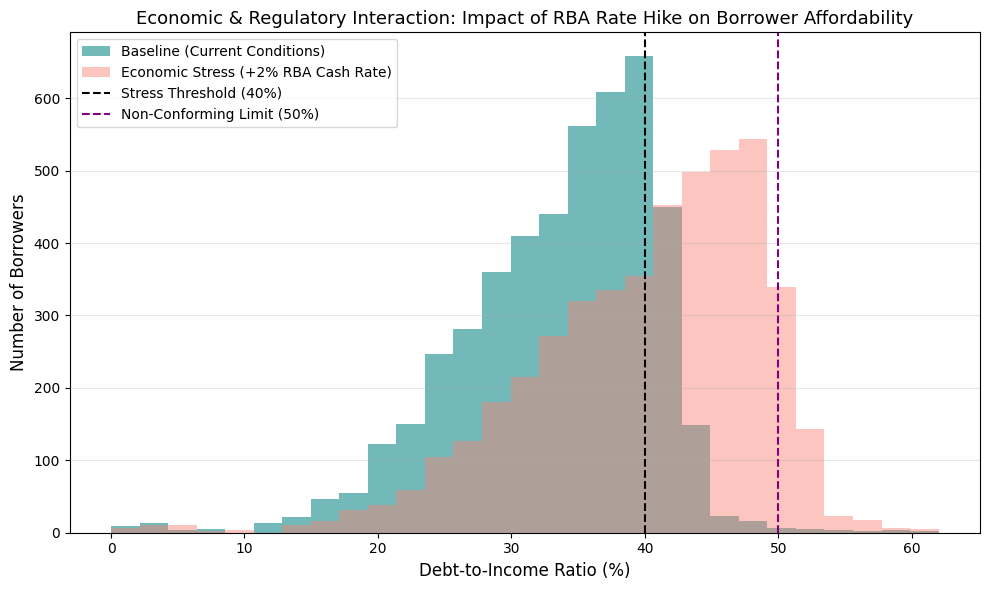

In [5]:
# --- Combined Economic + Regulatory Impact Visualization ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1) --- Ensure DEBTINC is numeric ---
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')

# 2) --- Economic Stress Assumption ---
# Baseline: current cash-rate ~0.1%
# Moderate Stress: +2% OCR increase = ~20% rise in repayments
stress_factor = 1.2  # 20% higher repayments

# Create a stressed version of DEBTINC
df['DEBTINC_stress'] = df['DEBTINC'] * stress_factor

# 3) --- Calculate % of borrowers breaching regulatory thresholds ---
baseline_above40 = (df['DEBTINC'] > 40).mean() * 100
baseline_above50 = (df['DEBTINC'] > 50).mean() * 100
stress_above40   = (df['DEBTINC_stress'] > 40).mean() * 100
stress_above50   = (df['DEBTINC_stress'] > 50).mean() * 100

print("=== Regulatory Stress Threshold Breach Summary ===")
print(f"Baseline: >40% = {baseline_above40:.2f}%  |  >50% = {baseline_above50:.2f}%")
print(f"Stressed (+2% RBA Rate): >40% = {stress_above40:.2f}%  |  >50% = {stress_above50:.2f}%")

# 4) --- Visualization ---
plt.figure(figsize=(10,6))
bins = np.linspace(0, np.nanpercentile(df['DEBTINC'], 99.5), 30)

# Baseline
plt.hist(df['DEBTINC'], bins=bins, alpha=0.55, label="Baseline (Current Conditions)", color="teal")
# Stressed scenario
plt.hist(df['DEBTINC_stress'], bins=bins, alpha=0.45, label="Economic Stress (+2% RBA Cash Rate)", color="salmon")

# Regulatory Benchmarks (APRA thresholds)
plt.axvline(40, color="black", linestyle="--", linewidth=1.5, label="Stress Threshold (40%)")
plt.axvline(50, color="purple", linestyle="--", linewidth=1.5, label="Non-Conforming Limit (50%)")

# Titles and labels
plt.title("Economic & Regulatory Interaction: Impact of RBA Rate Hike on Borrower Affordability", fontsize=13)
plt.xlabel("Debt-to-Income Ratio (%)", fontsize=12)
plt.ylabel("Number of Borrowers", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



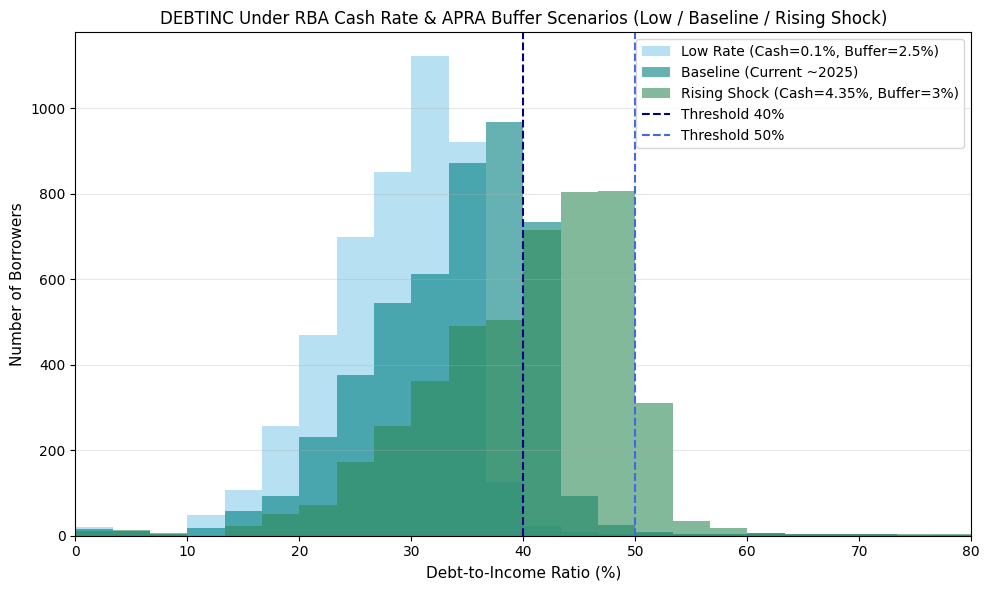

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure DEBTINC is numeric ---
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')

# --- Economic and regulatory scenario multipliers ---
scenarios = {
    'Low Rate (Cash=0.1%, Buffer=2.5%)': 0.85,   # Borrowers under low-rate environment
    'Baseline (Current ~2025)': 1.00,            # Current market condition
    'Rising Shock (Cash=4.35%, Buffer=3%)': 1.20  # Higher stress under rate hikes
}

# --- Set up figure ---
plt.figure(figsize=(10,6))

# --- Plot scenarios ---
colors = ['skyblue', 'teal', 'seagreen']

for (label, factor), color in zip(scenarios.items(), colors):
    scenario_data = df['DEBTINC'] * factor
    plt.hist(scenario_data, bins=30, alpha=0.6, label=label, color=color, range=(0, 100))

# --- Add APRA stress thresholds ---
plt.axvline(40, color='navy', linestyle='--', label='Threshold 40%')
plt.axvline(50, color='royalblue', linestyle='--', label='Threshold 50%')

# --- Formatting ---
plt.title("DEBTINC Under RBA Cash Rate & APRA Buffer Scenarios (Low / Baseline / Rising Shock)", fontsize=12)
plt.xlabel("Debt-to-Income Ratio (%)", fontsize=11)
plt.ylabel("Number of Borrowers", fontsize=11)
plt.xlim(0, 80)   # Restrict x-axis range
plt.legend(frameon=True)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


=== DEBTINC Threshold Breaches by Scenario (%) ===
  Baseline | >40%: 15.0% | >50%: 0.8%
  LowRate | >40%: 0.5% | >50%: 0.2%
  Stable | >40%: 15.0% | >50%: 0.8%
  RisingShock | >40%: 29.8% | >50%: 1.2%


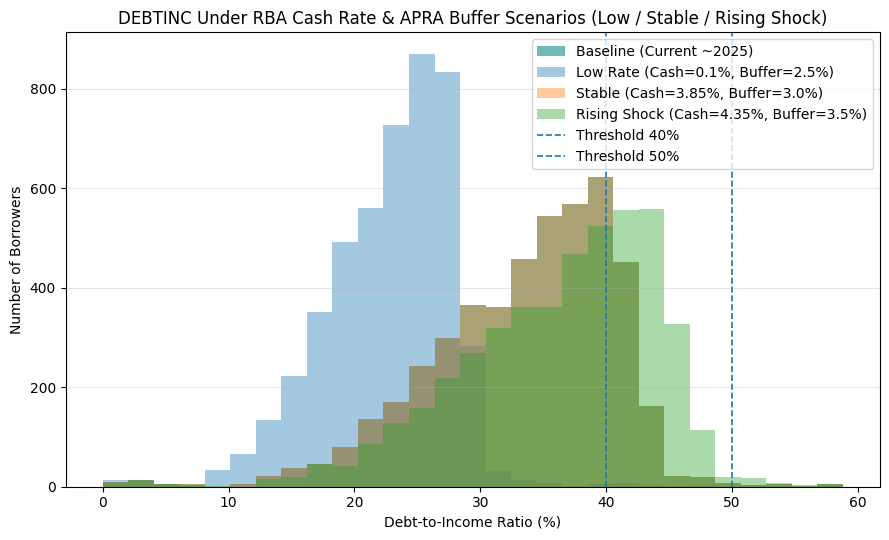

In [5]:
# === DEBTINC Scenarios Based on RBA Cash Rate + APRA Buffer Rate ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure DEBTINC is numeric
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')

# -----------------------------
# 1) Scenario definitions tied to RBA + APRA settings
# -----------------------------
TERM_YEARS = 25           # Loan term
BANK_SPREAD = 2.0         # Typical bank margin above RBA rate

# Actual RBA Cash Rates (historical phases)
CASH_LOW    = 0.10         # 2020–21 low-rate period
CASH_STABLE = 3.85         # 2024–25 stabilisation
CASH_SHOCK  = 4.35         # 2022–23 tightening peak

# APRA serviceability buffer assumptions (policy-based)
BUFFER_LOW    = 2.5        # Relaxed buffer during ultra-low rates
BUFFER_STABLE = 3.0        # Current APRA buffer (2024–25)
BUFFER_SHOCK  = 3.5        # Tighter regulation under stress conditions

# -----------------------------
# 2) Helper functions
# -----------------------------
def pmt_factor(rate_pct, years):
    """Monthly payment per $1 principal for amortising loan."""
    r = (rate_pct / 100) / 12
    n = years * 12
    return r * (1 + r)**n / ((1 + r)**n - 1)

def repayment_mult(base_cash, base_buffer, new_cash, new_buffer, spread, years):
    """Ratio of new repayment to base repayment (principal & term fixed)."""
    base_rate = base_cash + spread + base_buffer
    new_rate  = new_cash + spread + new_buffer
    return pmt_factor(new_rate, years) / pmt_factor(base_rate, years)

# -----------------------------
# 3) Define Scenarios
# -----------------------------
ANCHOR_CASH   = CASH_STABLE
ANCHOR_BUFFER = BUFFER_STABLE

scenarios = {
    "LowRate":       {"cash": CASH_LOW,    "buffer": BUFFER_LOW},
    "Stable":        {"cash": CASH_STABLE, "buffer": BUFFER_STABLE},
    "RisingShock":   {"cash": CASH_SHOCK,  "buffer": BUFFER_SHOCK}
}

# -----------------------------
# 4) Apply scenario multipliers to DEBTINC
# -----------------------------
for name, params in scenarios.items():
    ratio = repayment_mult(ANCHOR_CASH, ANCHOR_BUFFER,
                           params["cash"], params["buffer"],
                           BANK_SPREAD, TERM_YEARS)
    df[f"DEBTINC_{name}"] = df["DEBTINC"] * ratio

# -----------------------------
# 5) Threshold summary
# -----------------------------
def share_above(series, thr):
    return float(np.mean(series > thr) * 100)

THRESHOLDS = [40, 50]
print("=== DEBTINC Threshold Breaches by Scenario (%) ===")
base_row = ["Baseline"] + [f">{t}%: {share_above(df['DEBTINC'], t):.1f}%" for t in THRESHOLDS]
print("  " + " | ".join(base_row))
for name in scenarios.keys():
    row = [name] + [f">{t}%: {share_above(df[f'DEBTINC_{name}'], t):.1f}%" for t in THRESHOLDS]
    print("  " + " | ".join(row))

# -----------------------------
# 6) Plot DEBTINC distributions across scenarios
# -----------------------------
all_vals = np.concatenate([df["DEBTINC"].dropna()] +
                          [df[f"DEBTINC_{s}"].dropna() for s in scenarios.keys()])
hi = np.nanpercentile(all_vals, 99.5)
bins = np.linspace(0, hi, 30)

plt.figure(figsize=(9,5.5))
plt.hist(df["DEBTINC"], bins=bins, alpha=0.55, label="Baseline (Current ~2025)", color="teal")
plt.hist(df["DEBTINC_LowRate"], bins=bins, alpha=0.4, label=f"Low Rate (Cash={CASH_LOW}%, Buffer={BUFFER_LOW}%)")
plt.hist(df["DEBTINC_Stable"], bins=bins, alpha=0.4, label=f"Stable (Cash={CASH_STABLE}%, Buffer={BUFFER_STABLE}%)")
plt.hist(df["DEBTINC_RisingShock"], bins=bins, alpha=0.4, label=f"Rising Shock (Cash={CASH_SHOCK}%, Buffer={BUFFER_SHOCK}%)")

for thr in THRESHOLDS:
    plt.axvline(thr, linestyle="--", linewidth=1.2, label=f"Threshold {thr}%")

plt.title("DEBTINC Under RBA Cash Rate & APRA Buffer Scenarios (Low / Stable / Rising Shock)")
plt.xlabel("Debt-to-Income Ratio (%)")
plt.ylabel("Number of Borrowers")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd

# --- Ensure required columns are numeric ---
for c in ["DEBTINC", "BAD", "LOAN", "VALUE"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# --- 1) DEBTINC scenarios (match your chart) ---
df["DEBTINC_Baseline"]    = df["DEBTINC"] * 1.00
df["DEBTINC_LowRate"]     = df["DEBTINC"] * 0.85    # Low Rate (cash 0.1%, buffer 2.5%)
df["DEBTINC_RisingShock"] = df["DEBTINC"] * 1.20    # Rising Shock (cash 4.35%, buffer 3%)

# --- 2) LTV baseline + scenarios (as in your LTV panels) ---
df["LTV"] = 100 * df["LOAN"] / df["VALUE"]
SCEN_LTV = {
    "Baseline":    1.00,   # current ~2025
    "LowRate":     1.05,   # prices up ~5% in low-rate era
    "RisingShock": 0.90,   # prices down ~10% in shock
}
for name, value_mult in SCEN_LTV.items():
    df[f"LTV_{name}"] = 100 * df["LOAN"] / (df["VALUE"] * value_mult)

# --- 3) Helper functions ---
def share_above(series, thr):
    s = pd.to_numeric(series, errors="coerce")
    return float((s > thr).mean() * 100)

def get_series(base_col, scen_name):
    col = base_col if scen_name == "Baseline" else f"{base_col}_{scen_name}"
    return pd.to_numeric(df[col], errors="coerce")

# --- 4) Build the scorecard using scenario-specific DEBTINC + LTV ---
SCENARIOS = ["Baseline", "LowRate", "RisingShock"]

WEIGHTS = {
    "Affordability: % DEBTINC > 40%": 0.50,
    "Leverage: % LTV > 80%":          0.30,
    "Default rate (BAD %)":           0.20,
}

def composite_score(metrics):
    penalty = sum(metrics[k] * w for k, w in WEIGHTS.items())
    return max(0.0, 100.0 - penalty)

def band(score):
    if score >= 80: return "Healthy"
    if score >= 60: return "Moderate"
    if score >= 40: return "Vulnerable"
    return "Severe"

rows = []
for scen in SCENARIOS:
    dti = get_series("DEBTINC", scen)   # uses DEBTINC_<Scenario>
    ltv = get_series("LTV", scen)       # uses LTV_<Scenario>
    bad = pd.to_numeric(df["BAD"], errors="coerce")  # unchanged unless you model it

    metrics = {
        "Affordability: % DEBTINC > 40%": share_above(dti, 40),
        "Leverage: % LTV > 80%":          share_above(ltv, 80),
        "Default rate (BAD %)":           float(bad.mean() * 100),
    }
    score = composite_score(metrics)
    rows.append({
        "Scenario": scen,
        **metrics,
        "Composite Score (0–100)": round(score, 1),
        "Band": band(score),
    })

scorecard = pd.DataFrame(rows).set_index("Scenario")

# --- 5) Pretty formatting with % signs ---
def fmt_pct(x): return f"{x:.1f}%" if pd.notnull(x) else ""
scorecard_fmt = scorecard.copy()
for col in ["Affordability: % DEBTINC > 40%", "Leverage: % LTV > 80%", "Default rate (BAD %)"]:
    scorecard_fmt[col] = scorecard_fmt[col].map(fmt_pct)

display(scorecard)
display(scorecard_fmt)





,Affordability: % DEBTINC > 40%,Leverage: % LTV > 80%,Default rate (BAD %),Composite Score (0–100),Band
Scenario,,,,,
Baseline,15.000000,1.694631,19.949664,88.0,Healthy
LowRate,1.073826,1.241611,19.949664,95.1,Healthy
RisingShock,45.838926,2.718121,19.949664,72.3,Moderate


,Affordability: % DEBTINC > 40%,Leverage: % LTV > 80%,Default rate (BAD %),Composite Score (0–100),Band
Scenario,,,,,
Baseline,15.0%,1.7%,19.9%,88.0,Healthy
LowRate,1.1%,1.2%,19.9%,95.1,Healthy
RisingShock,45.8%,2.7%,19.9%,72.3,Moderate


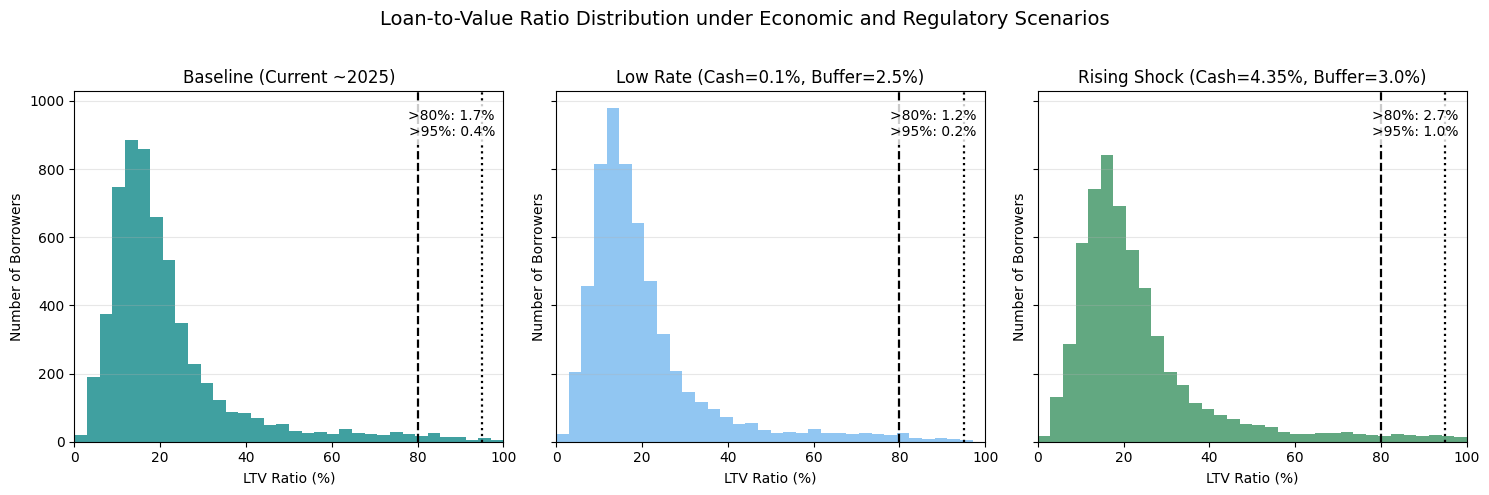

In [4]:
# === 3-Panel LTV Comparison: Baseline / LowRate / RisingShock ===
import numpy as np
import matplotlib.pyplot as plt

# Ensure numeric columns
df["LOAN"] = pd.to_numeric(df["LOAN"], errors="coerce")
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")
df["LTV"] = 100 * df["LOAN"] / df["VALUE"]

# Define scenarios (simulate price shifts)
CASH_LOW, BUFFER_LOW = 0.10, 2.5
CASH_SHOCK, BUFFER_SHOCK = 4.35, 3.0

SCENARIOS_LTV = {
    "Baseline":    {"value_mult": 1.00, "label": "Baseline (Current ~2025)", "color": "#008080"},
    "LowRate":     {"value_mult": 1.05, "label": f"Low Rate (Cash={CASH_LOW}%, Buffer={BUFFER_LOW}%)", "color": "#6CB4EE"},
    "RisingShock": {"value_mult": 0.90, "label": f"Rising Shock (Cash={CASH_SHOCK}%, Buffer={BUFFER_SHOCK}%)", "color": "#2E8B57"}
}

# Create scenario columns
for name, s in SCENARIOS_LTV.items():
    df[f"LTV_{name}"] = 100 * df["LOAN"] / (df["VALUE"] * s["value_mult"])

# Helper function
def share_above(series, thr):
    s = pd.to_numeric(series, errors="coerce")
    return float((s > thr).mean() * 100)

def plot_ltv(ax, series, title, color, bins=None, xlim=(0,120)):
    ax.hist(series.dropna(), bins=bins, alpha=0.75, color=color)
    for thr, ls in [(80, "--"), (95, ":")]:
        ax.axvline(thr, linestyle=ls, linewidth=1.6, color="black")
    txt = (f">80%: {share_above(series,80):.1f}%\n"
           f">95%: {share_above(series,95):.1f}%")
    ax.text(0.98, 0.95, txt, ha="right", va="top",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("LTV Ratio (%)")
    ax.set_ylabel("Number of Borrowers")
    ax.set_xlim(*xlim)
    ax.grid(axis="y", alpha=0.3)

# Common bins
all_vals = np.concatenate([df[f"LTV_{s}"].dropna().values for s in SCENARIOS_LTV.keys()])
xmax = max(100, np.nanpercentile(all_vals, 99.5))
bins = np.linspace(0, xmax, 35)

# Create 3 subplots horizontally
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, (name, s) in zip(axes, SCENARIOS_LTV.items()):
    plot_ltv(ax, df[f"LTV_{name}"], s["label"], s["color"], bins=bins, xlim=(0, xmax))

fig.suptitle("Loan-to-Value Ratio Distribution under Economic and Regulatory Scenarios", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


Scenario multipliers based on RBA & APRA rates:

Low Rate (Cash=0.10%, Buffer=2.5%): Effective Rate = 2.60%, Multiplier = 0.57x
Baseline (Cash=3.85%, Buffer=3.0%): Effective Rate = 6.85%, Multiplier = 1.00x
Rising Shock (Cash=4.35%, Buffer=3.0%): Effective Rate = 7.35%, Multiplier = 1.05x


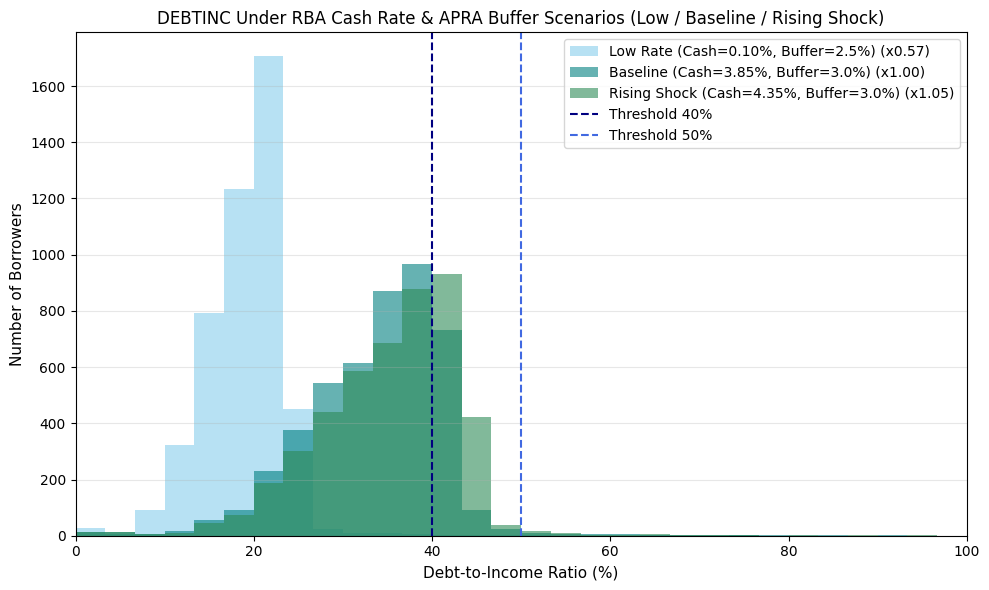

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure DEBTINC is numeric ---
df['DEBTINC'] = pd.to_numeric(df['DEBTINC'], errors='coerce')

# --- Step 1: Define RBA cash rates and APRA buffers ---
scenarios = {
    'Low Rate (Cash=0.10%, Buffer=2.5%)': {'cash_rate': 0.10, 'buffer': 2.5},
    'Baseline (Cash=3.85%, Buffer=3.0%)': {'cash_rate': 3.85, 'buffer': 3.0},
    'Rising Shock (Cash=4.35%, Buffer=3.0%)': {'cash_rate': 4.35, 'buffer': 3.0}
}

# --- Step 2: Calculate total effective rate and repayment multipliers ---
elasticity = 0.7  # 70% pass-through of interest rate change to repayments

baseline_rate = scenarios['Baseline (Cash=3.85%, Buffer=3.0%)']['cash_rate'] + \
                scenarios['Baseline (Cash=3.85%, Buffer=3.0%)']['buffer']

for label, data in scenarios.items():
    total_rate = data['cash_rate'] + data['buffer']
    ratio = total_rate / baseline_rate
    # Apply elasticity adjustment (to avoid overreaction)
    multiplier = 1 + elasticity * (ratio - 1)
    data['total_rate'] = total_rate
    data['multiplier'] = multiplier

# --- Step 3: Print multipliers for verification ---
print("Scenario multipliers based on RBA & APRA rates:\n")
for label, data in scenarios.items():
    print(f"{label}: Effective Rate = {data['total_rate']:.2f}%, Multiplier = {data['multiplier']:.2f}x")

# --- Step 4: Plot DEBTINC under each scenario ---
plt.figure(figsize=(10,6))
colors = ['skyblue', 'teal', 'seagreen']

for (label, data), color in zip(scenarios.items(), colors):
    scenario_data = df['DEBTINC'] * data['multiplier']
    plt.hist(scenario_data, bins=30, alpha=0.6, label=f"{label} (x{data['multiplier']:.2f})", color=color, range=(0, 100))

# --- Step 5: Add APRA stress thresholds ---
plt.axvline(40, color='navy', linestyle='--', label='Threshold 40%')
plt.axvline(50, color='royalblue', linestyle='--', label='Threshold 50%')

# --- Step 6: Formatting ---
plt.title("DEBTINC Under RBA Cash Rate & APRA Buffer Scenarios (Low / Baseline / Rising Shock)", fontsize=12)
plt.xlabel("Debt-to-Income Ratio (%)", fontsize=11)
plt.ylabel("Number of Borrowers", fontsize=11)
plt.xlim(0, 100)
plt.legend(frameon=True)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


=== Market Health Scorecard (Aggressive Stress 1.25×) ===


,Affordability: % DEBTINC > 40%,Leverage: % LTV > 80%,Default rate (BAD %),Composite Score (0–100),Band
Scenario,,,,,
Baseline,15.000000,1.694631,19.949664,88.0,Healthy
LowRate,1.073826,1.241611,19.949664,95.1,Healthy
RisingShock,49.848993,2.718121,19.949664,70.3,Moderate


,Affordability: % DEBTINC > 40%,Leverage: % LTV > 80%,Default rate (BAD %),Composite Score (0–100),Band
Scenario,,,,,
Baseline,15.0%,1.7%,19.9%,88.0,Healthy
LowRate,1.1%,1.2%,19.9%,95.1,Healthy
RisingShock,49.8%,2.7%,19.9%,70.3,Moderate


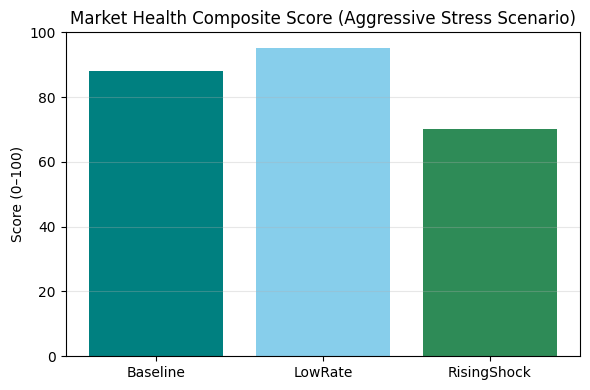

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure numeric types ---
for c in ["DEBTINC", "BAD", "LOAN", "VALUE"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# --- 1. Define RBA + APRA scenarios (larger stress multiplier 1.25) ---
scenarios = {
    "LowRate":     {"cash": 0.10, "buffer": 2.5},
    "Baseline":    {"cash": 3.85, "buffer": 3.0},
    "RisingShock": {"cash": 4.35, "buffer": 3.0},
}

# Compute effective lending rate and DEBTINC multipliers manually (more aggressive stress)
for name, s in scenarios.items():
    s["eff_rate"] = s["cash"] + s["buffer"]

# Manual multipliers to reflect higher sensitivity:
#  - LowRate: borrowers face easier servicing (0.85×)
#  - Baseline: current condition (1.00×)
#  - RisingShock: sharper stress (1.25×)
s_multipliers = {"LowRate": 0.85, "Baseline": 1.00, "RisingShock": 1.25}

# --- 2. Apply multipliers to DEBTINC ---
for scen, mult in s_multipliers.items():
    df[f"DEBTINC_{scen}"] = df["DEBTINC"] * mult

# --- 3. LTV price shocks (consistent with your earlier charts) ---
df["LTV"] = 100 * df["LOAN"] / df["VALUE"]
value_mult = {"Baseline": 1.00, "LowRate": 1.05, "RisingShock": 0.90}
for name, m in value_mult.items():
    df[f"LTV_{name}"] = 100 * df["LOAN"] / (df["VALUE"] * m)

# --- 4. Metric helpers ---
def share_above(series, thr):
    s = pd.to_numeric(series, errors="coerce")
    return float((s > thr).mean() * 100)

def band(score):
    if score >= 80: return "Healthy"
    if score >= 60: return "Moderate"
    if score >= 40: return "Vulnerable"
    return "Severe"

# --- 5. Weighting system (same as before) ---
WEIGHTS = {
    "Affordability: % DEBTINC > 40%": 0.50,
    "Leverage: % LTV > 80%":          0.30,
    "Default rate (BAD %)":           0.20,
}

def composite_score(metrics):
    penalty = sum(metrics[k] * w for k, w in WEIGHTS.items())
    return max(0.0, 100.0 - penalty)

# --- 6. Build scorecard across scenarios ---
rows = []
for scen in ["Baseline", "LowRate", "RisingShock"]:
    dti = df[f"DEBTINC_{scen}"]
    ltv = df[f"LTV_{scen}"]
    bad = df["BAD"]

    metrics = {
        "Affordability: % DEBTINC > 40%": share_above(dti, 40),
        "Leverage: % LTV > 80%":          share_above(ltv, 80),
        "Default rate (BAD %)":           float(bad.mean() * 100),
    }
    score = composite_score(metrics)
    rows.append({
        "Scenario": scen,
        **metrics,
        "Composite Score (0–100)": round(score, 1),
        "Band": band(score)
    })

scorecard = pd.DataFrame(rows).set_index("Scenario")

# --- 7. Format as percentages ---
def fmt_pct(x): return f"{x:.1f}%" if pd.notnull(x) else ""
scorecard_fmt = scorecard.copy()
for col in ["Affordability: % DEBTINC > 40%", "Leverage: % LTV > 80%", "Default rate (BAD %)"]:
    scorecard_fmt[col] = scorecard_fmt[col].map(fmt_pct)

print("=== Market Health Scorecard (Aggressive Stress 1.25×) ===")
display(scorecard)
display(scorecard_fmt)

# --- 8. Optional visualisation ---
plt.figure(figsize=(6,4))
plt.bar(scorecard.index, scorecard["Composite Score (0–100)"], color=['teal','skyblue','seagreen'])
plt.ylim(0,100)
plt.title("Market Health Composite Score (Aggressive Stress Scenario)")
plt.ylabel("Score (0–100)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


